## Cek GPU

In [1]:
!nvidia-smi

Thu Jan  1 19:15:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Install Library

In [2]:
%pip install ultralytics gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.0 MB/s eta 0:00:00


## Matikan tracking Ultralytics

In [3]:
import ultralytics
from ultralytics import settings
print(f"Versi Ultralytics: {ultralytics.__version__}")

# Disable analytics and crash reporting
settings.update({"sync": False})

print(f"Tracking status (sync): {settings['sync']}")  # matikan tracking

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Versi Ultralytics: 8.3.245
Tracking status (sync): False


## Download Dataset dari Google Drive Link

In [4]:
# Hapus folder datasets (berisi gambar)
!rm -rf datasets

# Hapus folder project_batik (berisi hasil training sebelumnya)
!rm -rf project_batik

# Hapus file zip jika ingin bersih total
!rm -rf batik_dataset.zip

print("Folder berhasil dihapus.")

Folder berhasil dihapus.


In [ ]:
import gdown
import os

file_id = '...'

output_file = 'batik_dataset.zip'
url = f'https://drive.google.com/uc?id={file_id}'

if not os.path.exists(output_file):
    print("Sedang mendownload dataset...")
    gdown.download(url, output_file, quiet=False)
else:
    print("File zip sudah ada.")

# Unzip dataset
!unzip -q batik_dataset.zip -d datasets/
print("Dataset berhasil di-unzip ke folder 'datasets/'")

Sedang mendownload dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1WHipH1I6FOCWWMBsWTvwB2RSiQ8SPez4
From (redirected): https://drive.google.com/uc?id=1WHipH1I6FOCWWMBsWTvwB2RSiQ8SPez4&confirm=t&uuid=20b915c3-0d97-4fc6-b8b7-596b2d95908f
To: /content/batik_dataset.zip
100%|██████████| 185M/185M [00:06<00:00, 30.6MB/s]


Dataset berhasil di-unzip ke folder 'datasets/'


## Cari file Yaml

In [6]:
import yaml
import os

# Cari file data.yaml
yaml_path = None
for root, dirs, files in os.walk("datasets"):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        break

if yaml_path:
    print(f"File konfigurasi ditemukan di: {yaml_path}")

    # Baca dan perbaiki path
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    # Hapus path hardcode, ganti dengan path relatif Colab
    data['path'] = os.path.abspath(os.path.dirname(yaml_path))
    # Pastikan train/val menunjuk ke folder yang benar relative terhadap 'path'
    data['train'] = 'train/images'
    # Roboflow biasanya menamakan folder ini 'valid'
    data['val'] = 'valid/images'
    data['test'] = 'test/images' if 'test' in data else None

    # Simpan ulang
    with open(yaml_path, 'w') as f:
        yaml.dump(data, f)
    print("data.yaml berhasil diperbaiki untuk Colab.")
else:
    print("ERROR: data.yaml tidak ditemukan! Cek struktur folder datasets Anda.")

File konfigurasi ditemukan di: datasets/data.yaml
data.yaml berhasil diperbaiki untuk Colab.


## Pastikan semua gambar tidak ada anotasi rectangle

In [7]:
import os


def find_rectangle_labels(dataset_path):
    print(f"🔍 Scanning {dataset_path} for incompatible labels...")
    bad_files = []

    # Walk through all folders and subfolders
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(".txt") and file != "classes.txt":
                filepath = os.path.join(root, file)

                try:
                    with open(filepath, 'r') as f:
                        lines = f.readlines()

                    for i, line in enumerate(lines):
                        parts = line.strip().split()

                        # Ignore empty lines
                        if not parts:
                            continue

                        # CRITICAL CHECK:
                        # Detection labels have exactly 5 items (class, x, y, w, h).
                        # Segmentation labels must have > 5 items (class + at least 3 points).
                        if len(parts) == 5:
                            print(f"⚠️  PROBLEM FOUND: {filepath}")
                            print(f"    Line {i + 1}: {line.strip()}")
                            bad_files.append(filepath)
                            break  # Found a bad line, no need to check the rest of this file

                except Exception as e:
                    print(f"Error reading {filepath}: {e}")

    print("-" * 30)
    if bad_files:
        print(f"❌ Found {len(bad_files)} files with rectangle annotations.")
    else:
        print("✅ No rectangle annotations found. All labels appear to be polygons.")

    return bad_files

# --- UPDATE THIS PATH ---
# Example: "/content/datasets/coco8-seg" or "C:/projects/data"
dataset_path = "/content/datasets/"

# Run the function
bad_files_list = find_rectangle_labels(dataset_path)

🔍 Scanning /content/datasets/ for incompatible labels...
⚠️  PROBLEM FOUND: /content/datasets/README.dataset.txt
    Line 4: Provided by a Roboflow user
⚠️  PROBLEM FOUND: /content/datasets/README.roboflow.txt
    Line 9: * collect & organize images
------------------------------
❌ Found 2 files with rectangle annotations.


## Training

In [8]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

# --- MULAI TRAINING ---
results = model.train(
    data=yaml_path,     # Path otomatis dari blok sebelumnya
    epochs=100,          # 50 epoch cukup untuk percobaan awal
    imgsz=640,          # Ukuran standar
    batch=16,           # Aman untuk GPU T4 Colab
    # Stop kalau tidak ada peningkatan dalam 10 epoch (hemat waktu)
    patience=10,
    project='project_batik',  # Nama folder output
    name='hasil_training',
    exist_ok=True,      # Timpa folder jika sudah ada
    verbose=True
)

Ultralytics 8.3.245 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=hasil_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.

## Visualisasi Hasil Training

In [9]:
import os
from IPython.display import Image, display

# Path output training (sesuai setting project='project_batik', name='hasil_training')
output_dir = 'project_batik/hasil_training'

=== 1. Grafik Performa Training (Loss & mAP) ===


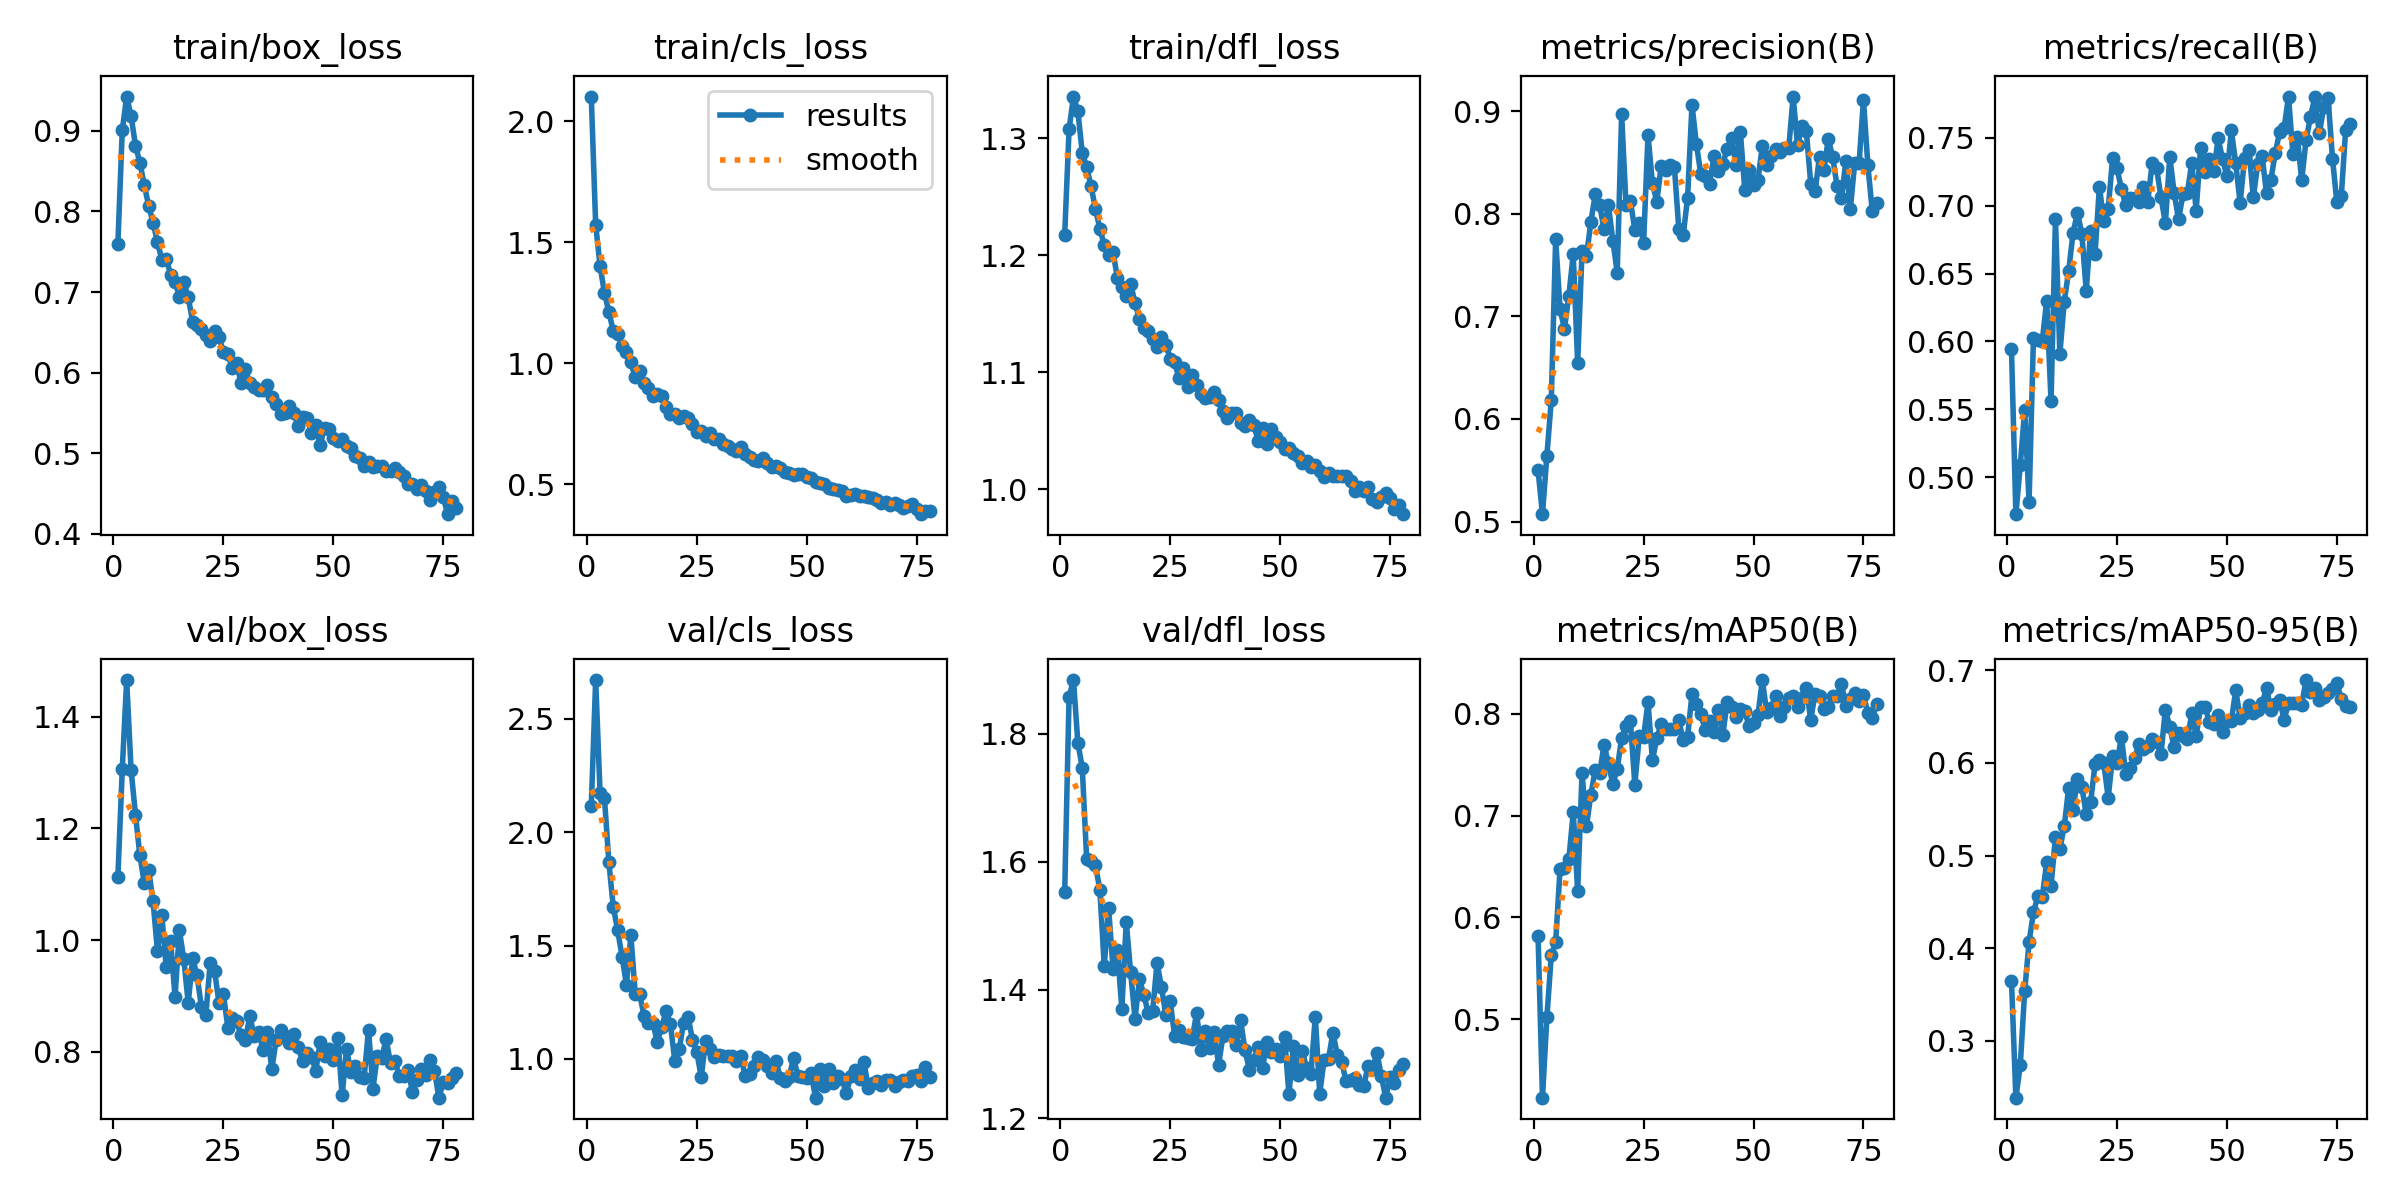

In [10]:

print("=== 1. Grafik Performa Training (Loss & mAP) ===")
# results.png berisi ringkasan Loss, Precision, Recall, dan mAP per epoch
results_path = os.path.join(output_dir, 'results.png')
display(Image(filename=results_path, width=800))


=== 2. Confusion Matrix ===


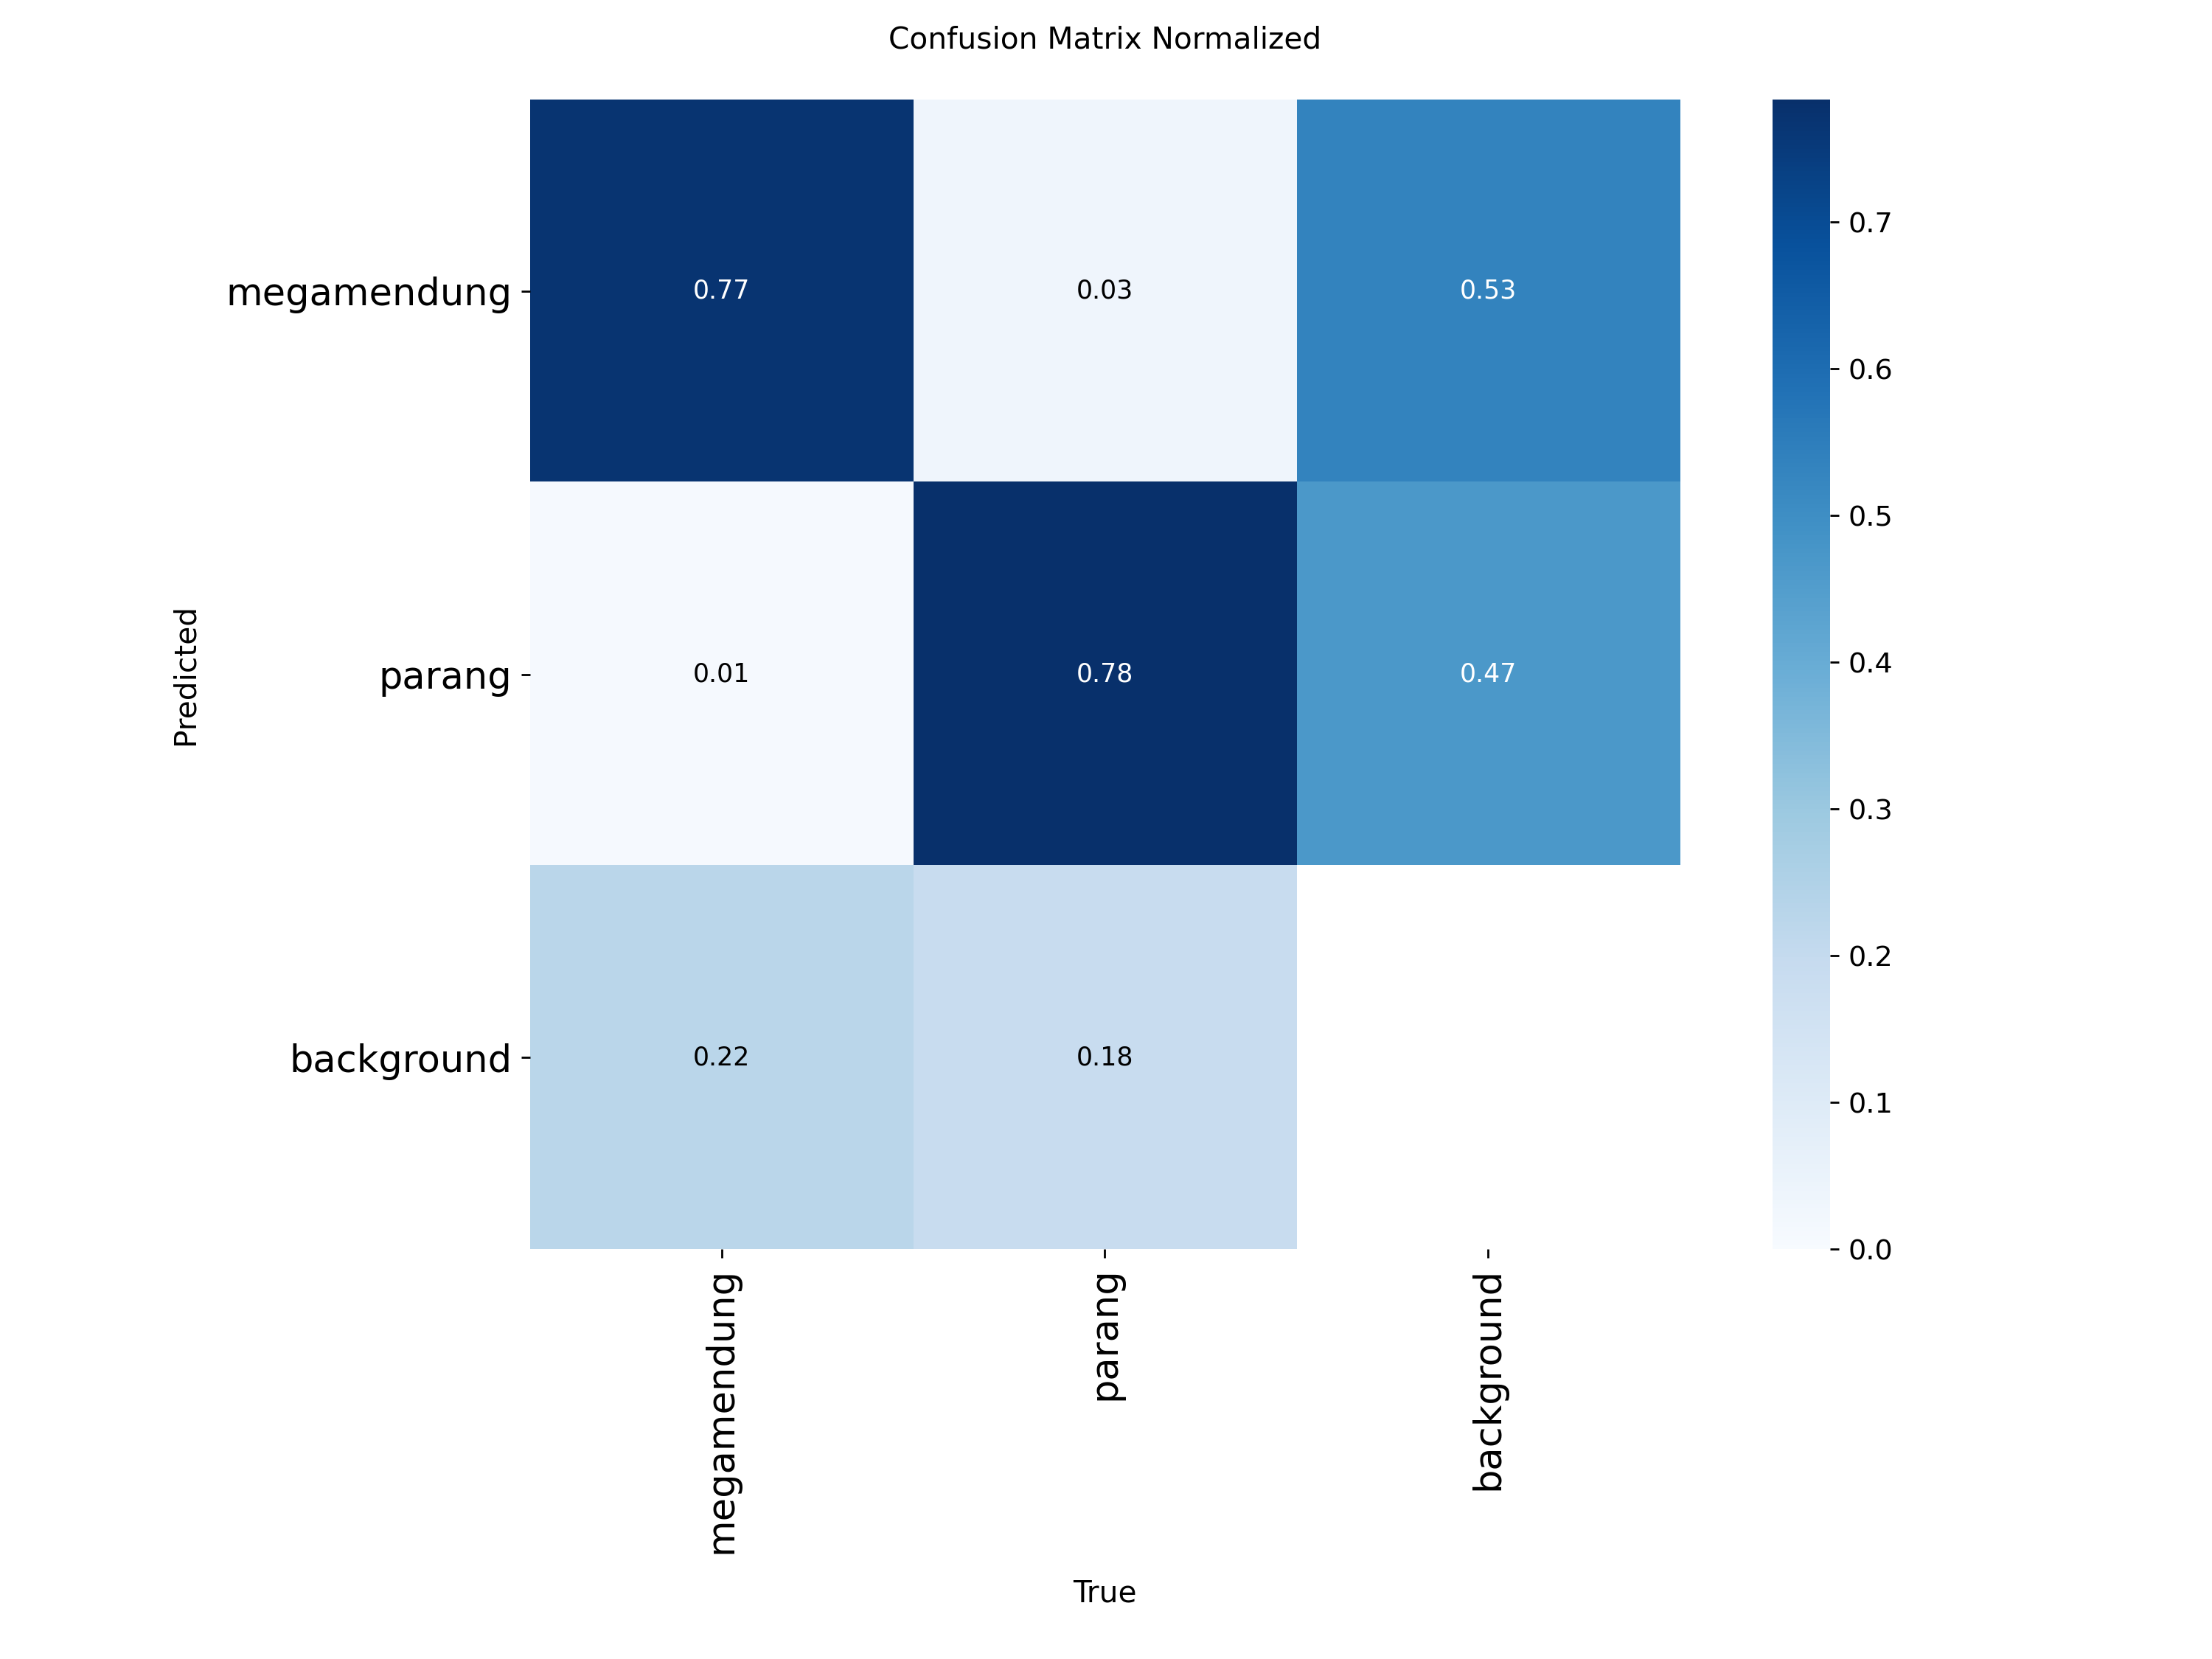

In [11]:

print("\n=== 2. Confusion Matrix ===")
# Melihat apakah Megamendung tertukar dengan Parang
cm_path = os.path.join(output_dir, 'confusion_matrix_normalized.png')
display(Image(filename=cm_path, width=600))


=== 3. Kurva Box ===


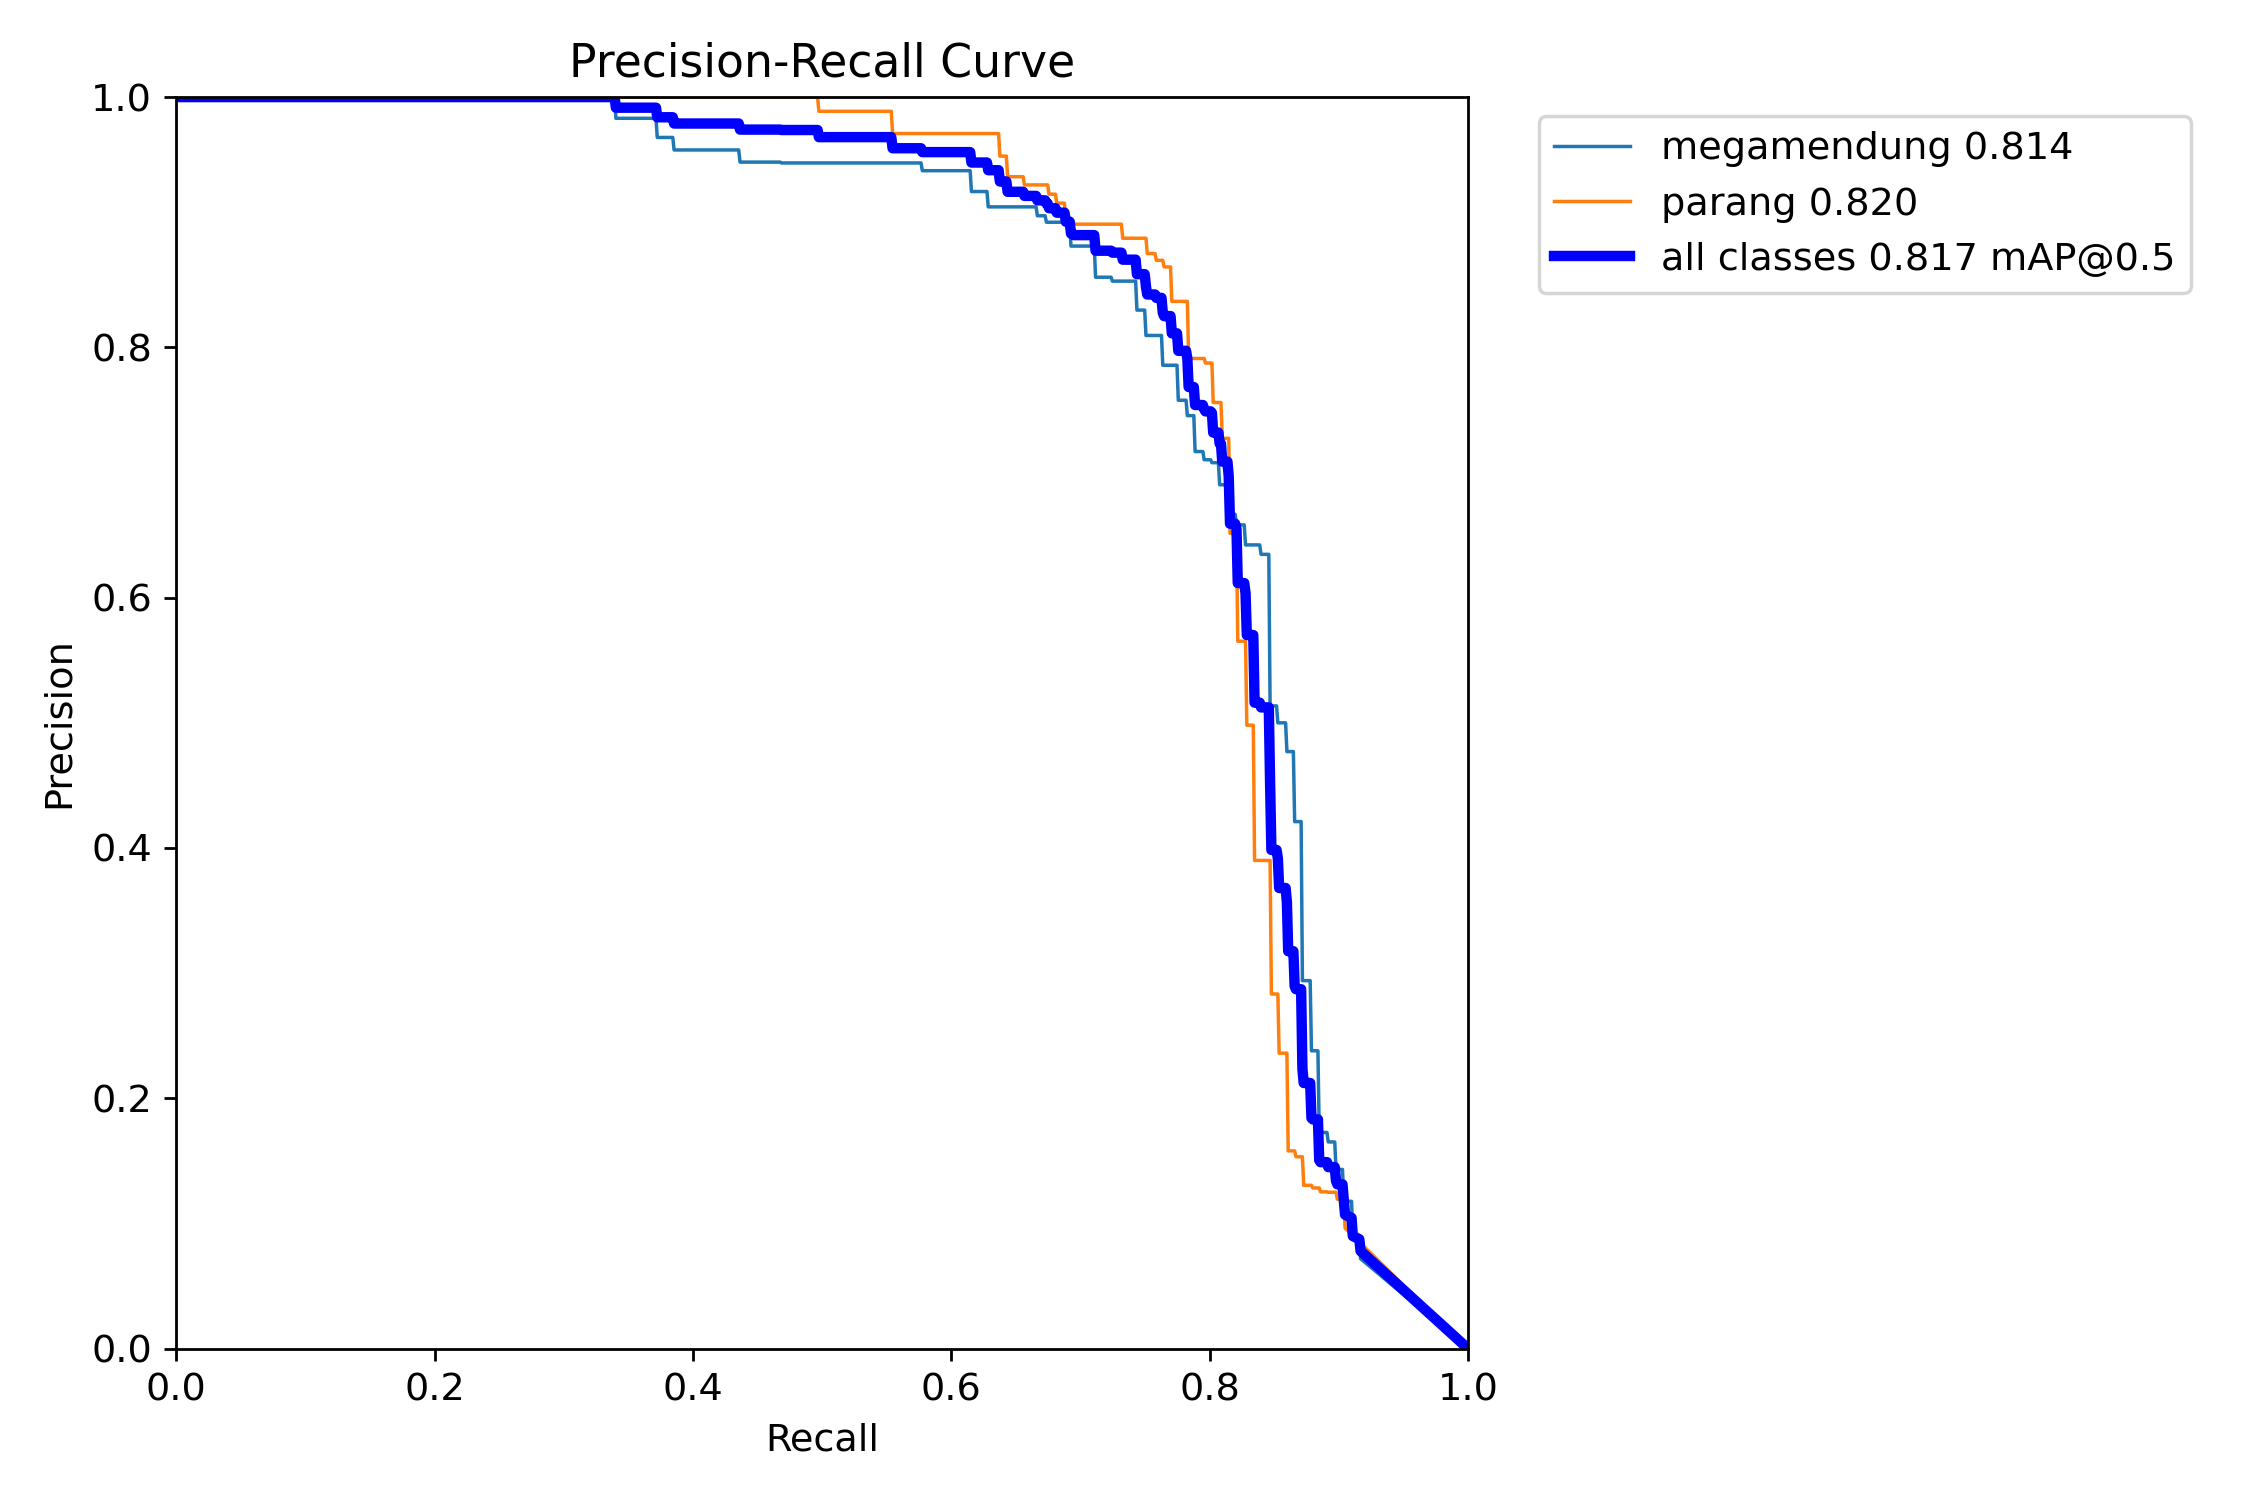

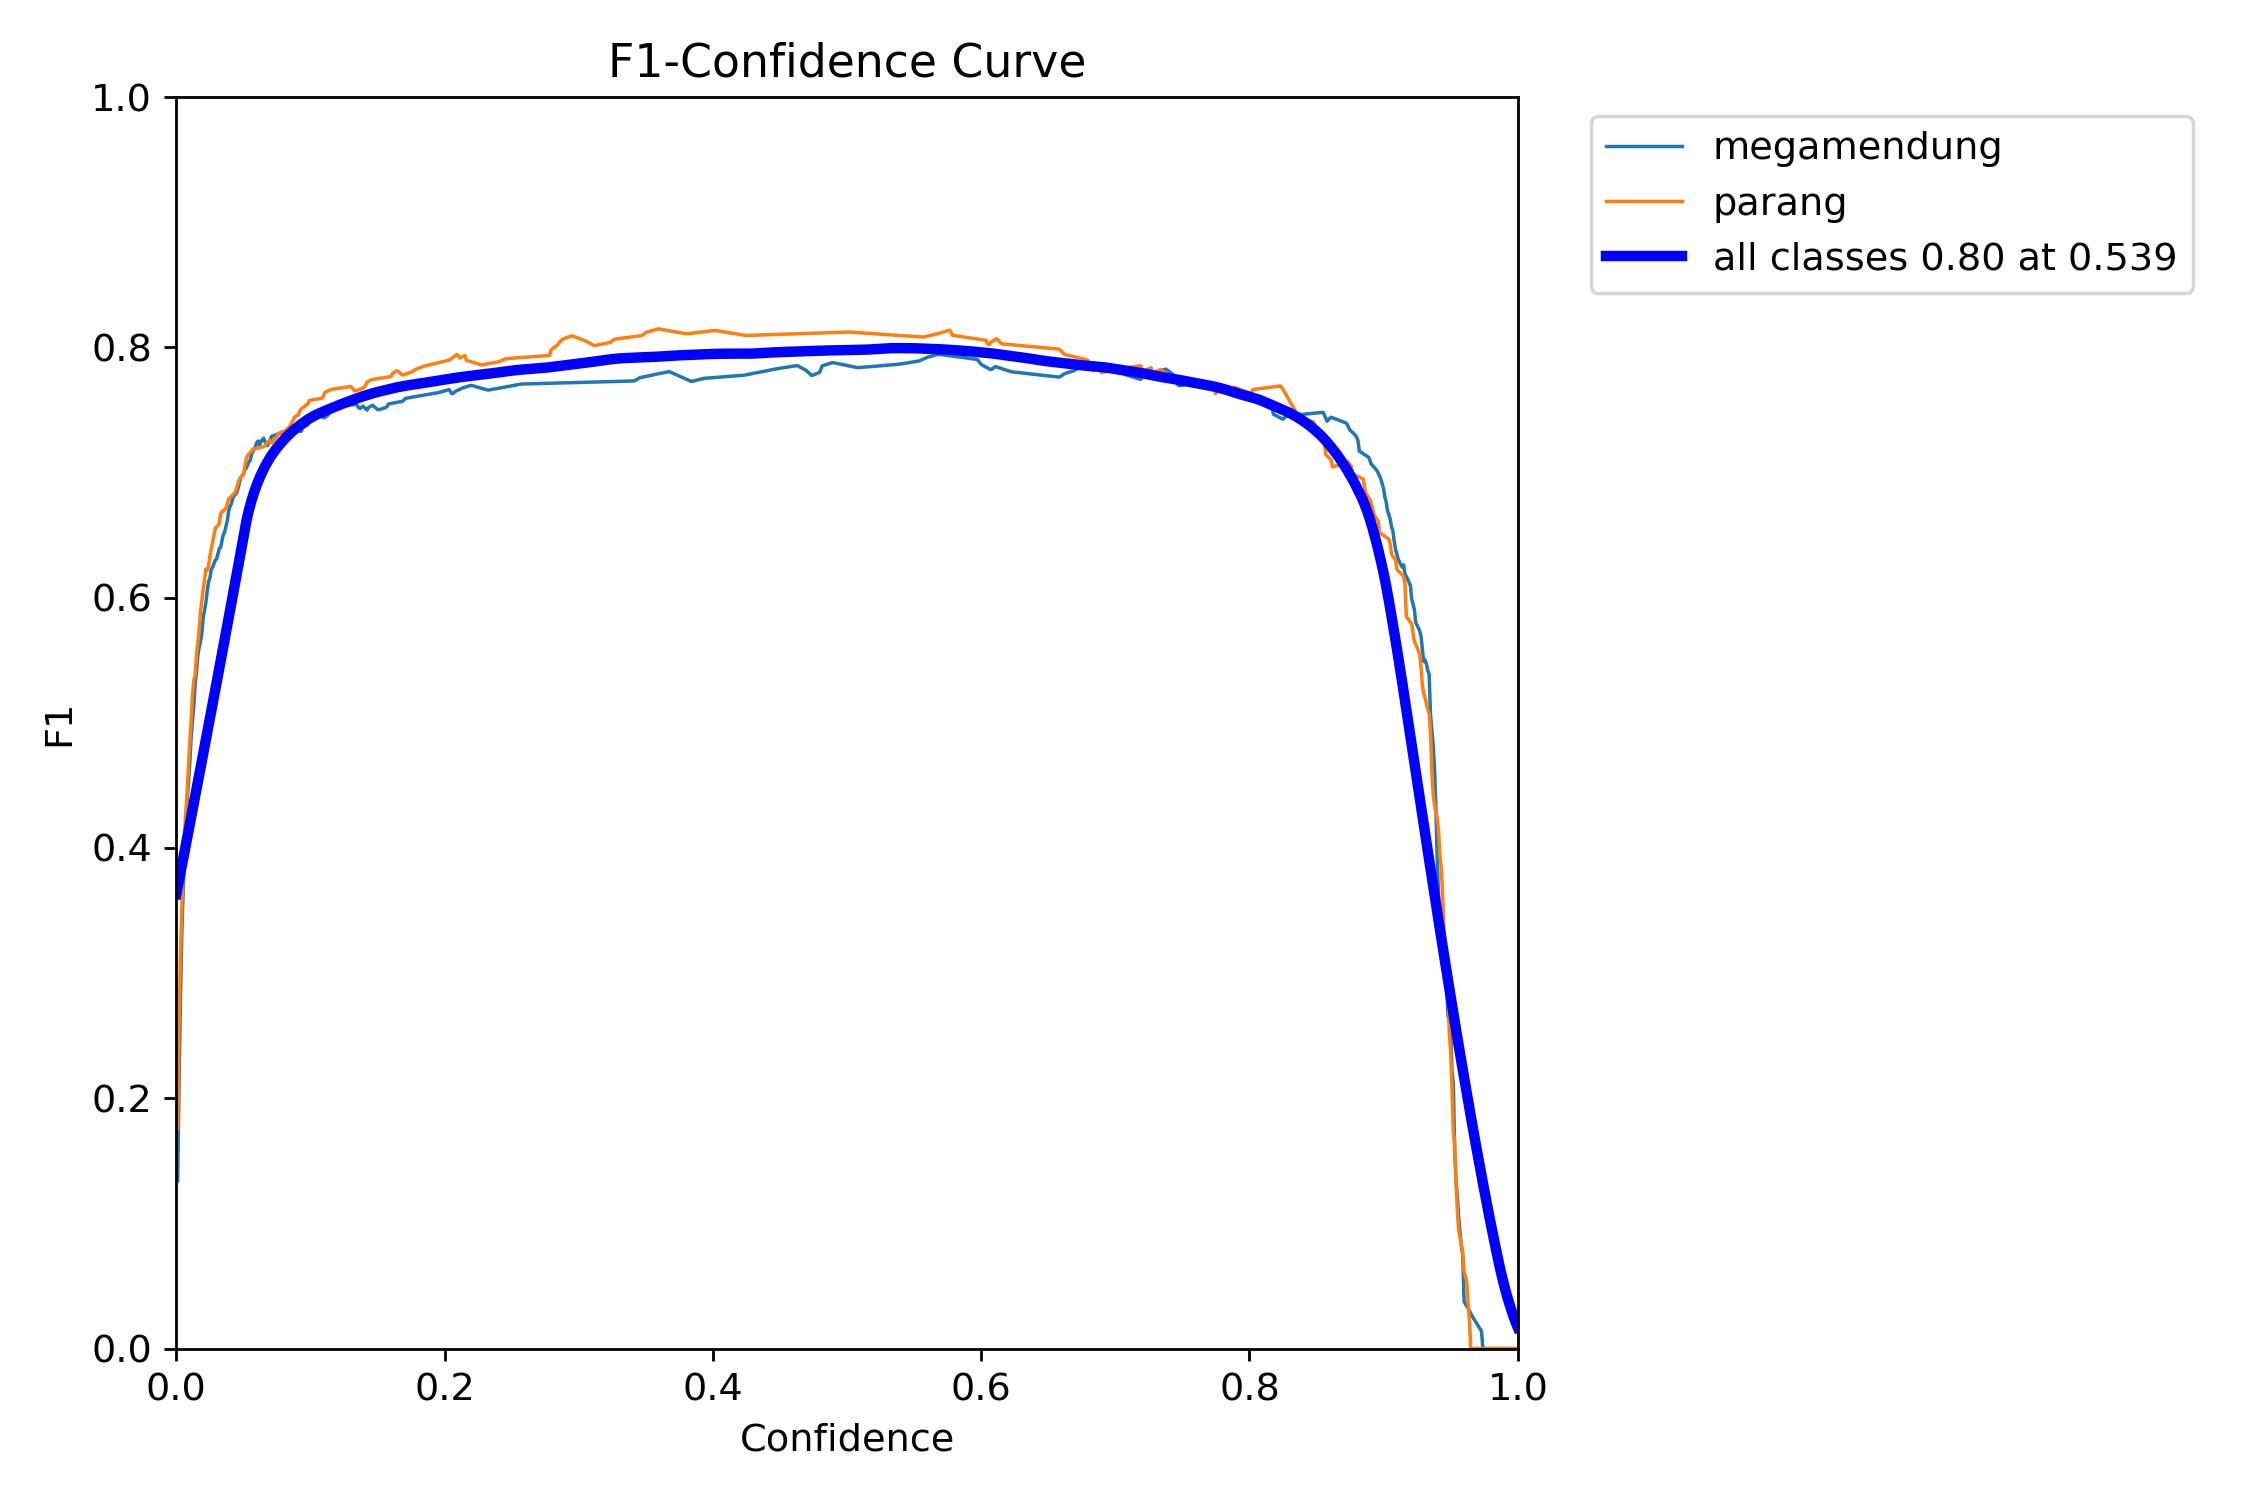

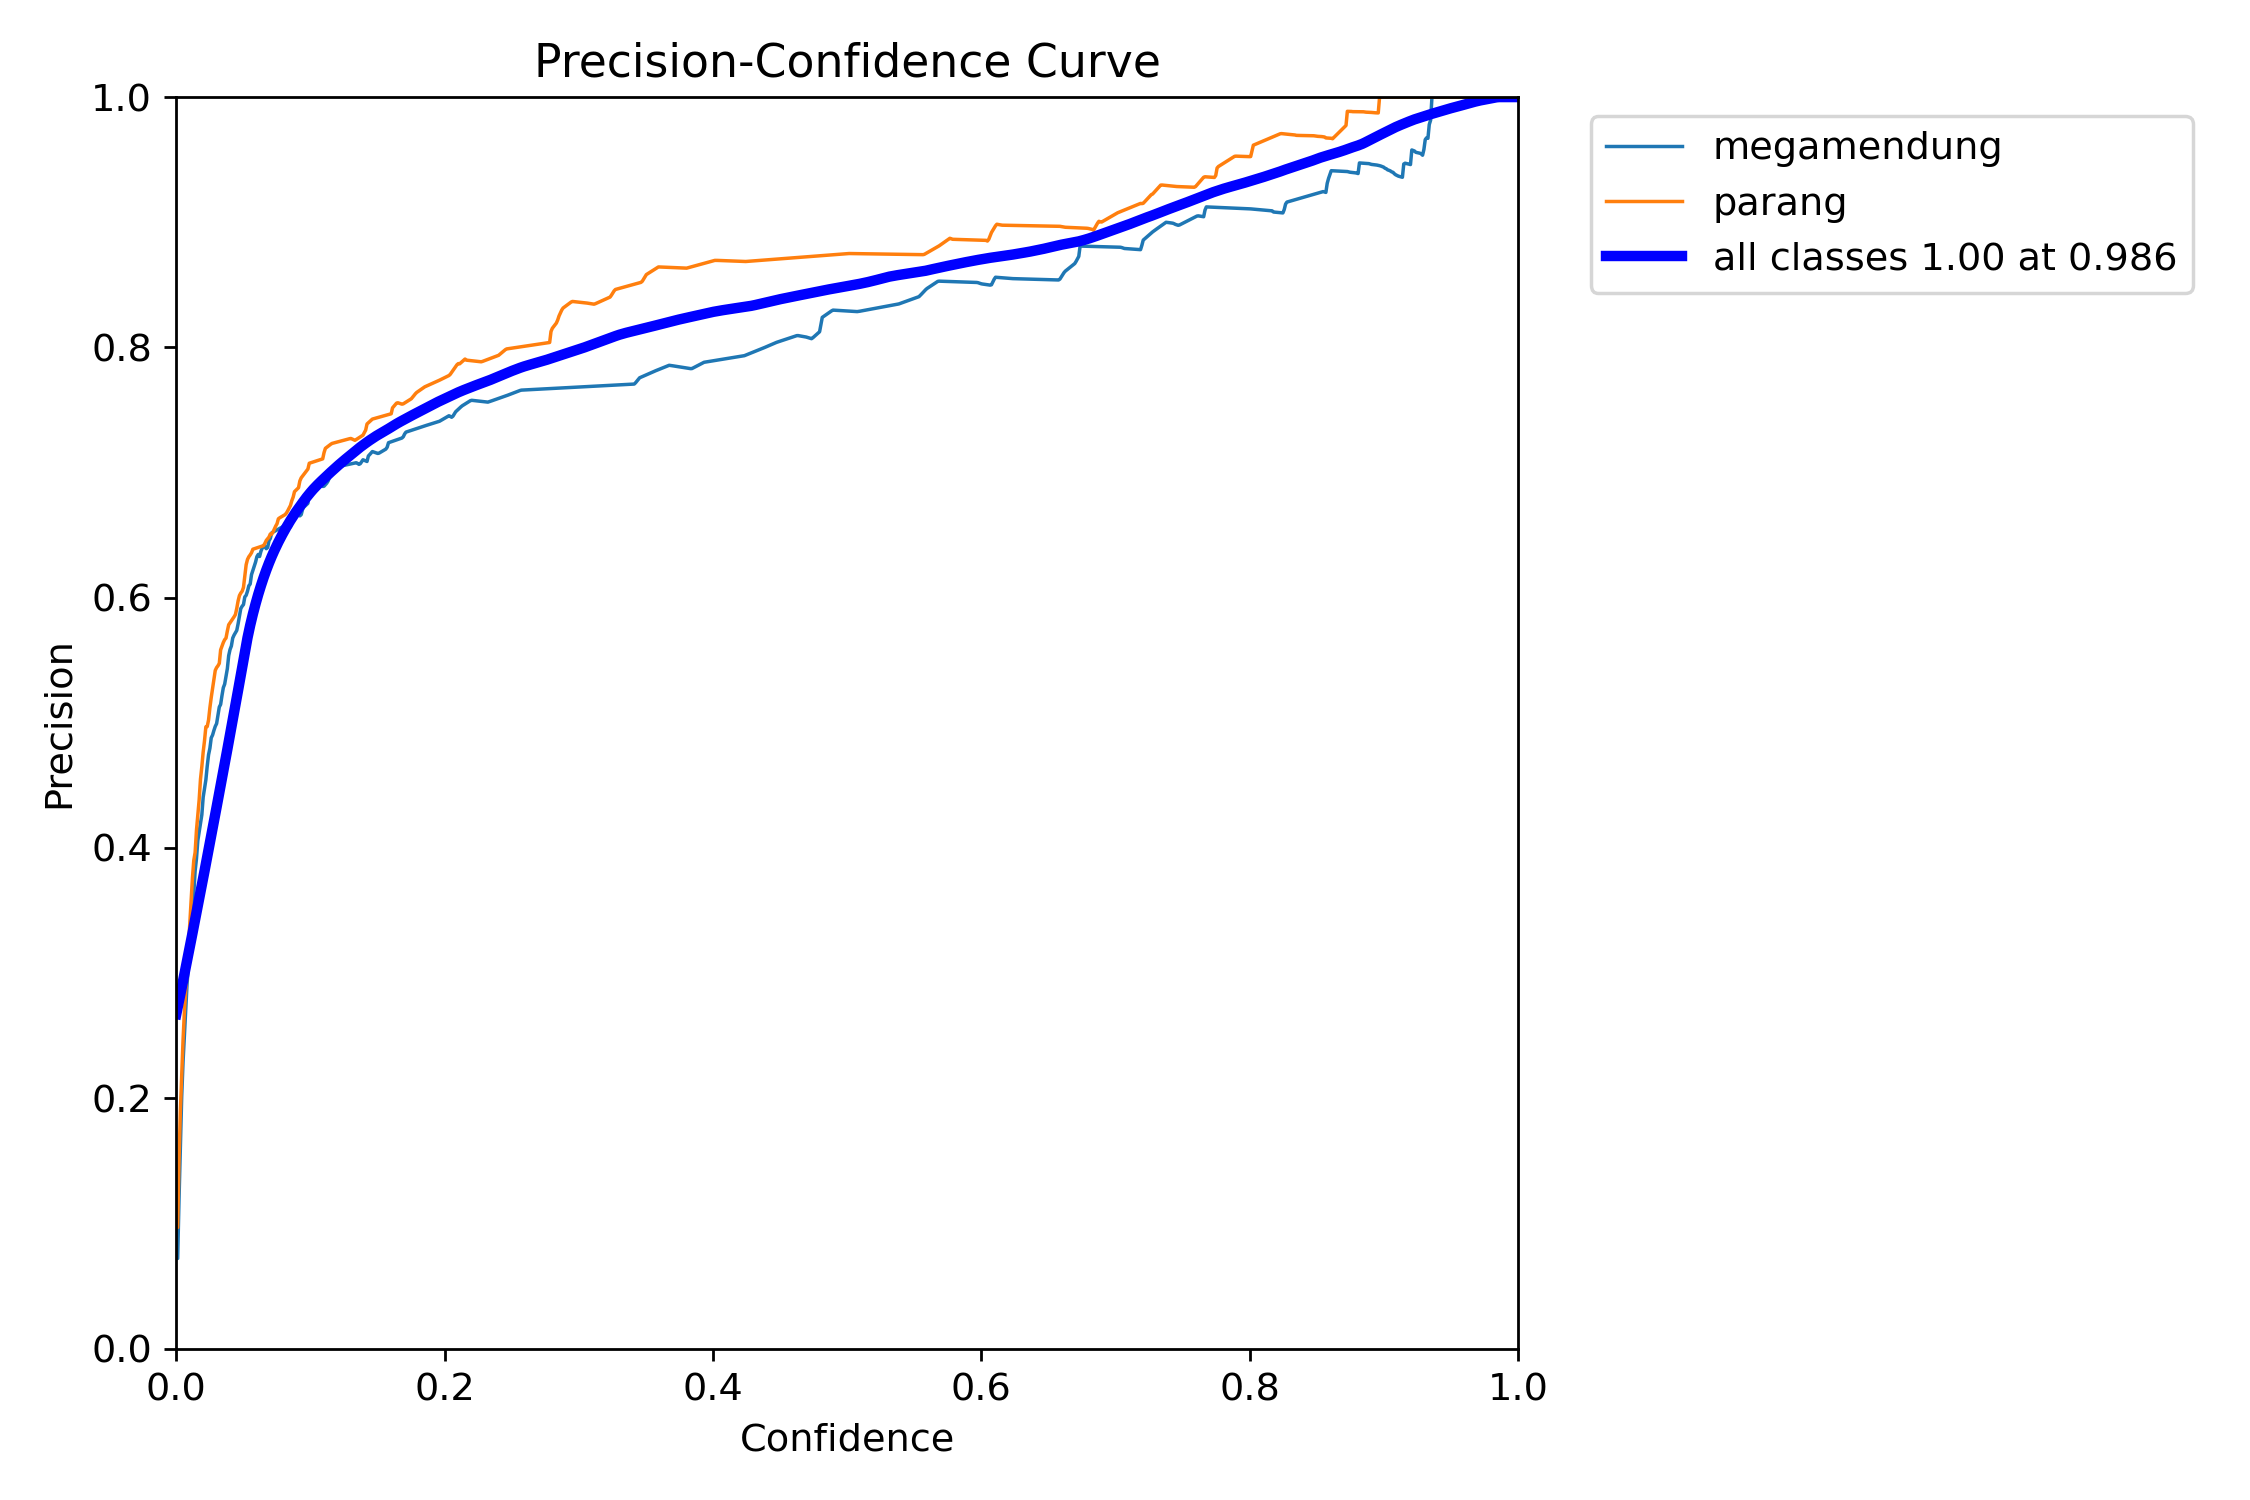

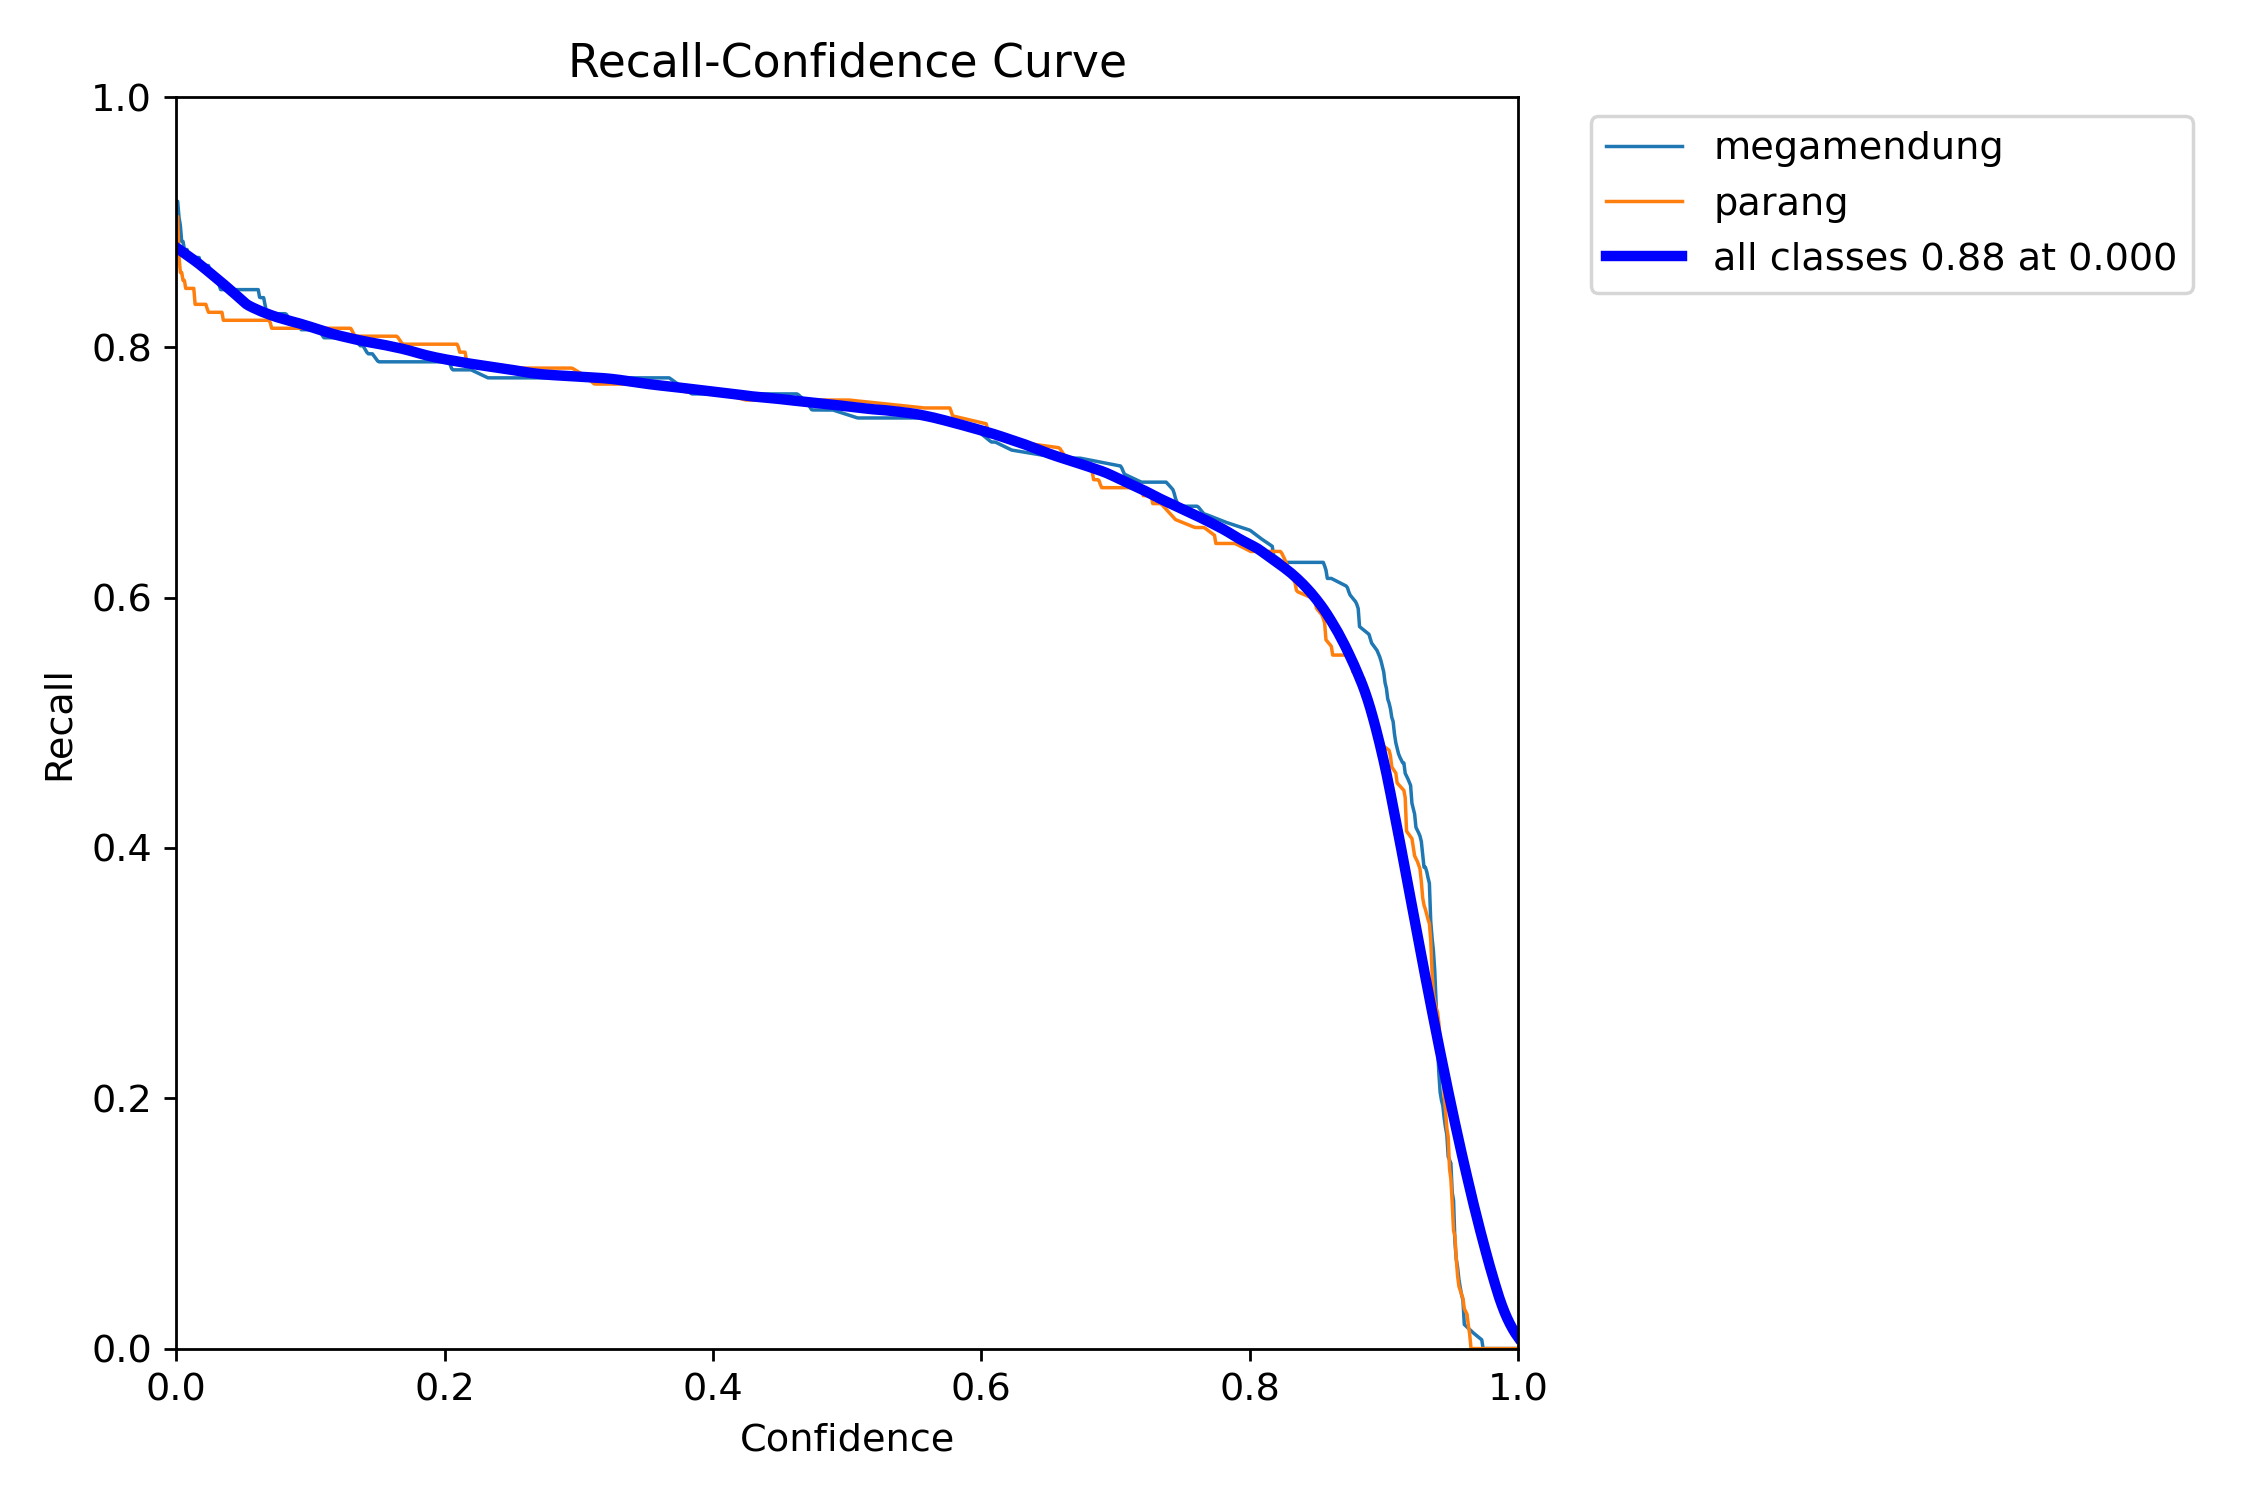

In [12]:

print("\n=== 3. Kurva Box ===")
# Semakin kurva mendekati pojok kanan atas, semakin bagus
display(Image(filename=os.path.join(output_dir, 'BoxPR_curve.png'), width=600))

display(Image(filename=os.path.join(output_dir, 'BoxF1_curve.png'), width=600))
display(Image(filename=os.path.join(output_dir, 'BoxP_curve.png'), width=600))
display(Image(filename=os.path.join(output_dir, 'BoxR_curve.png'), width=600))


=== 4. Contoh Hasil Prediksi pada Data Validasi ===


=== Batch 1 ===


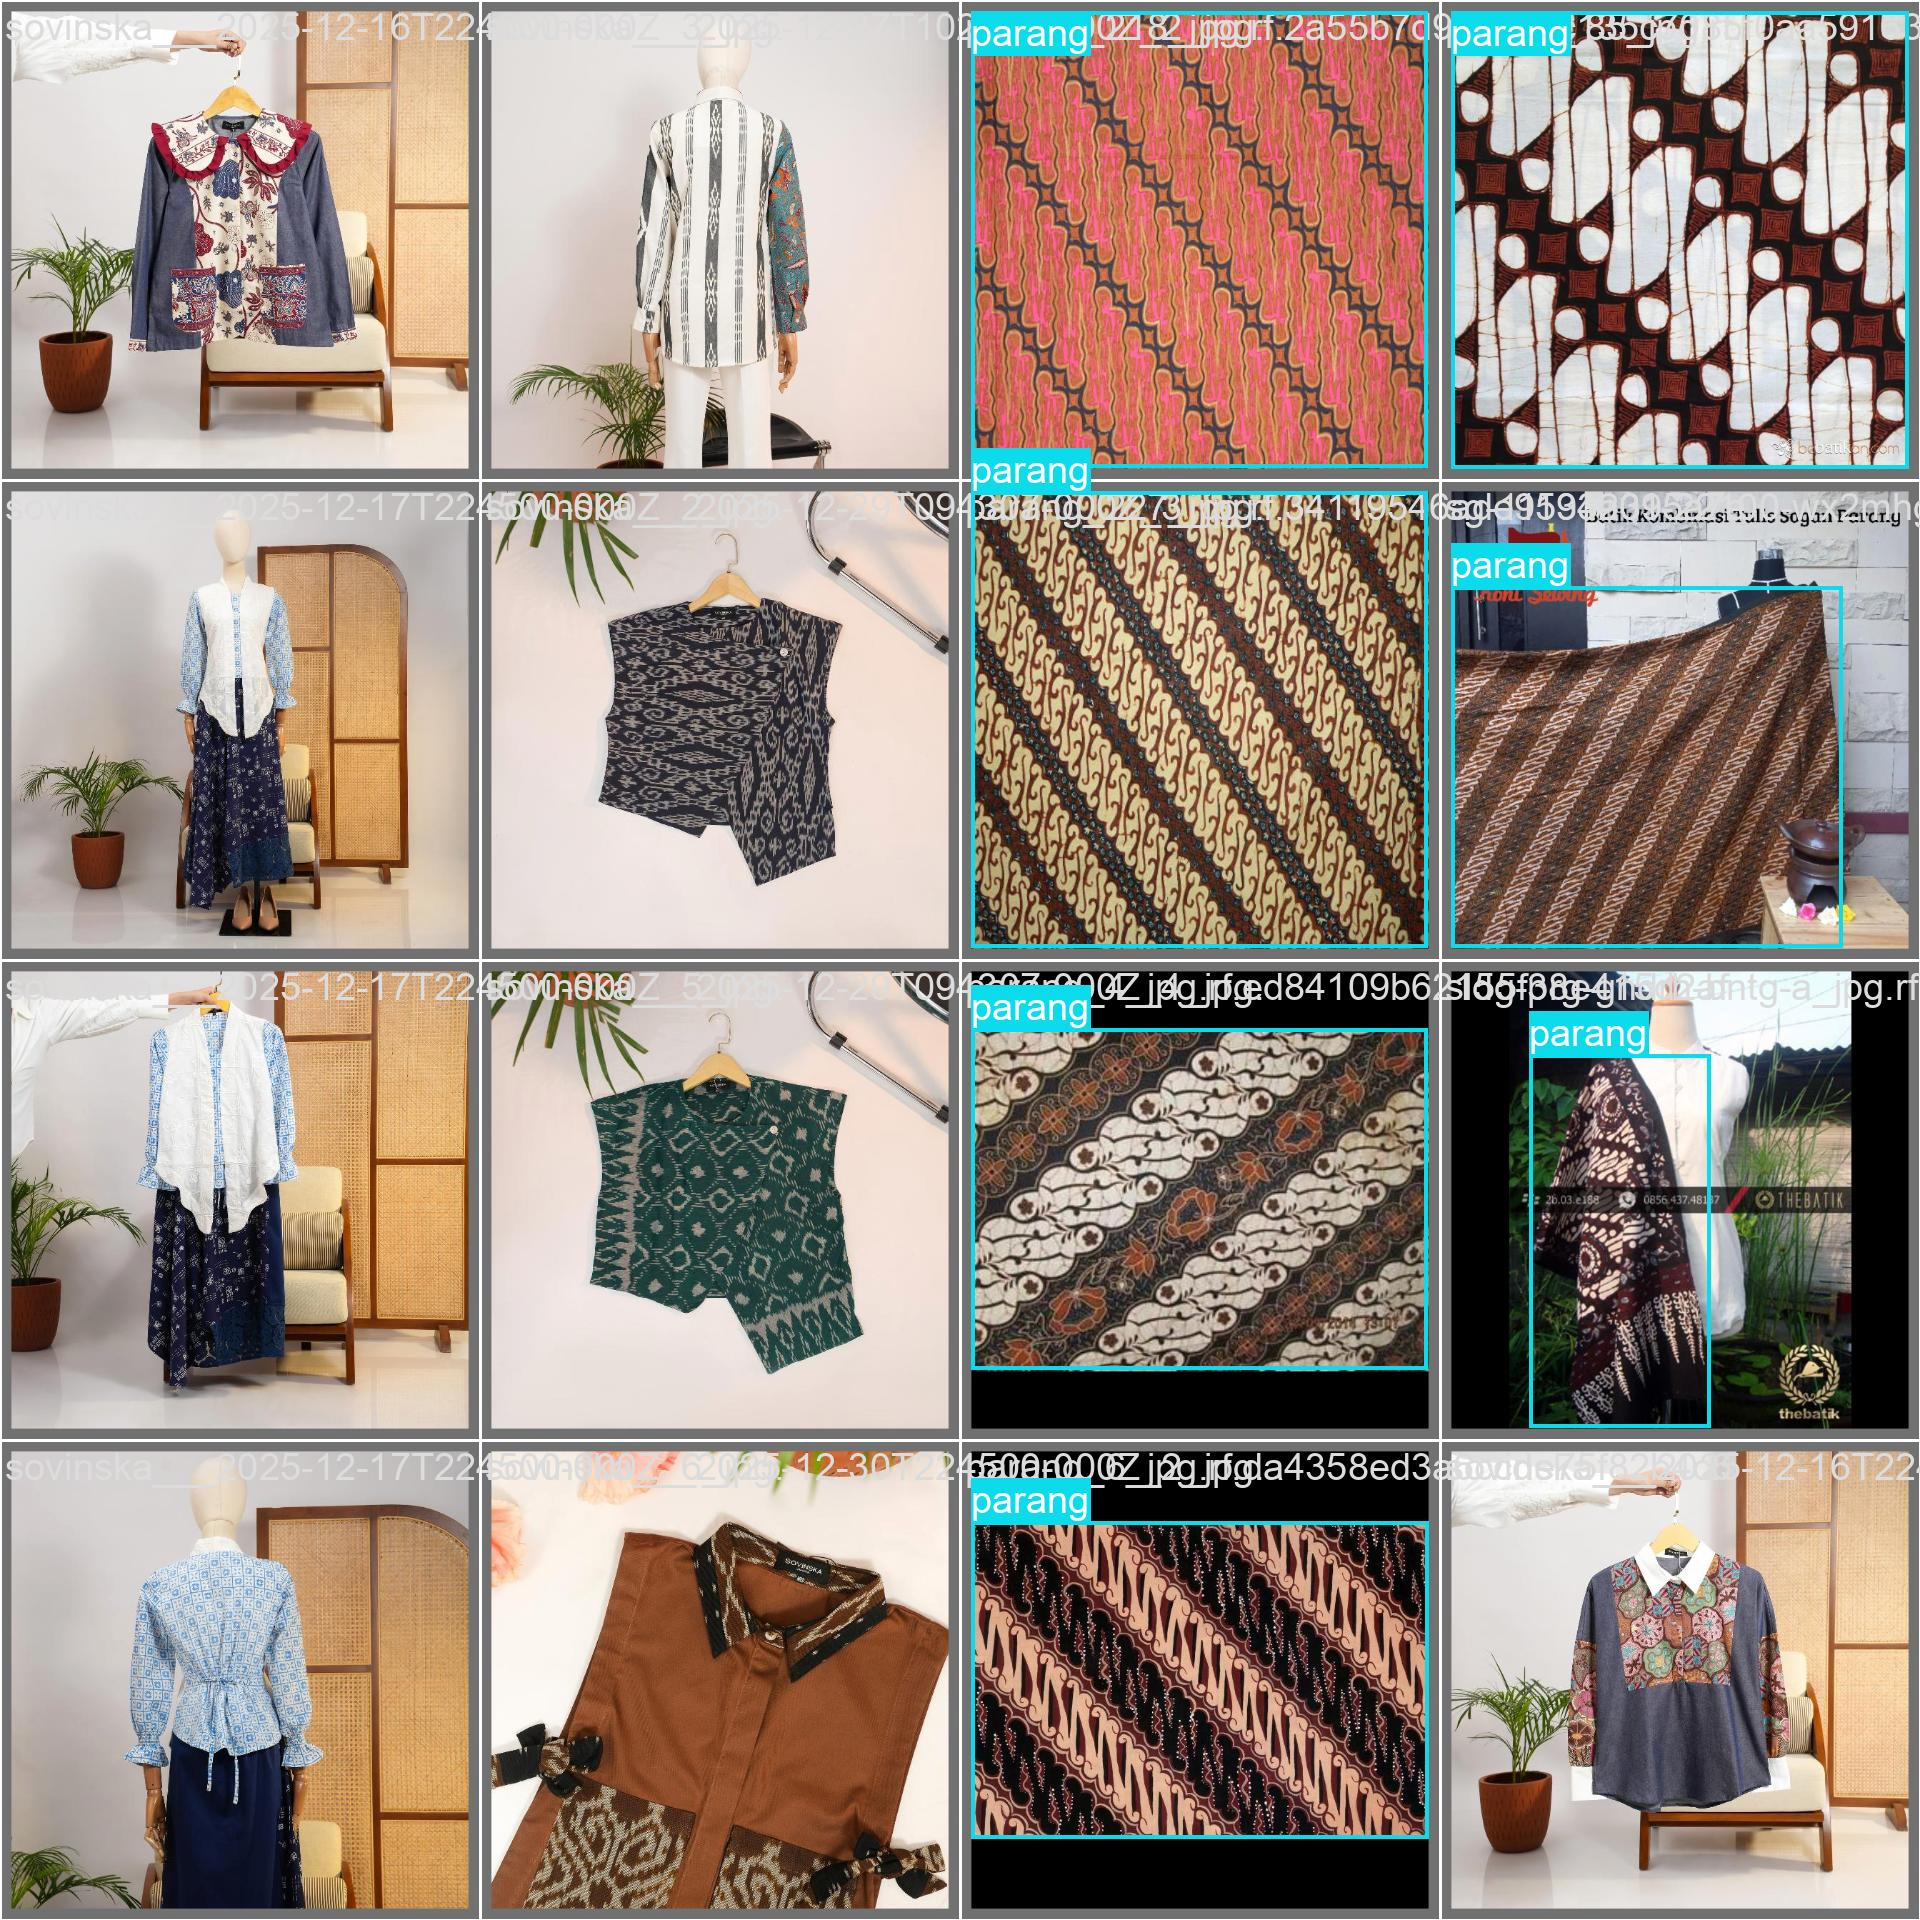

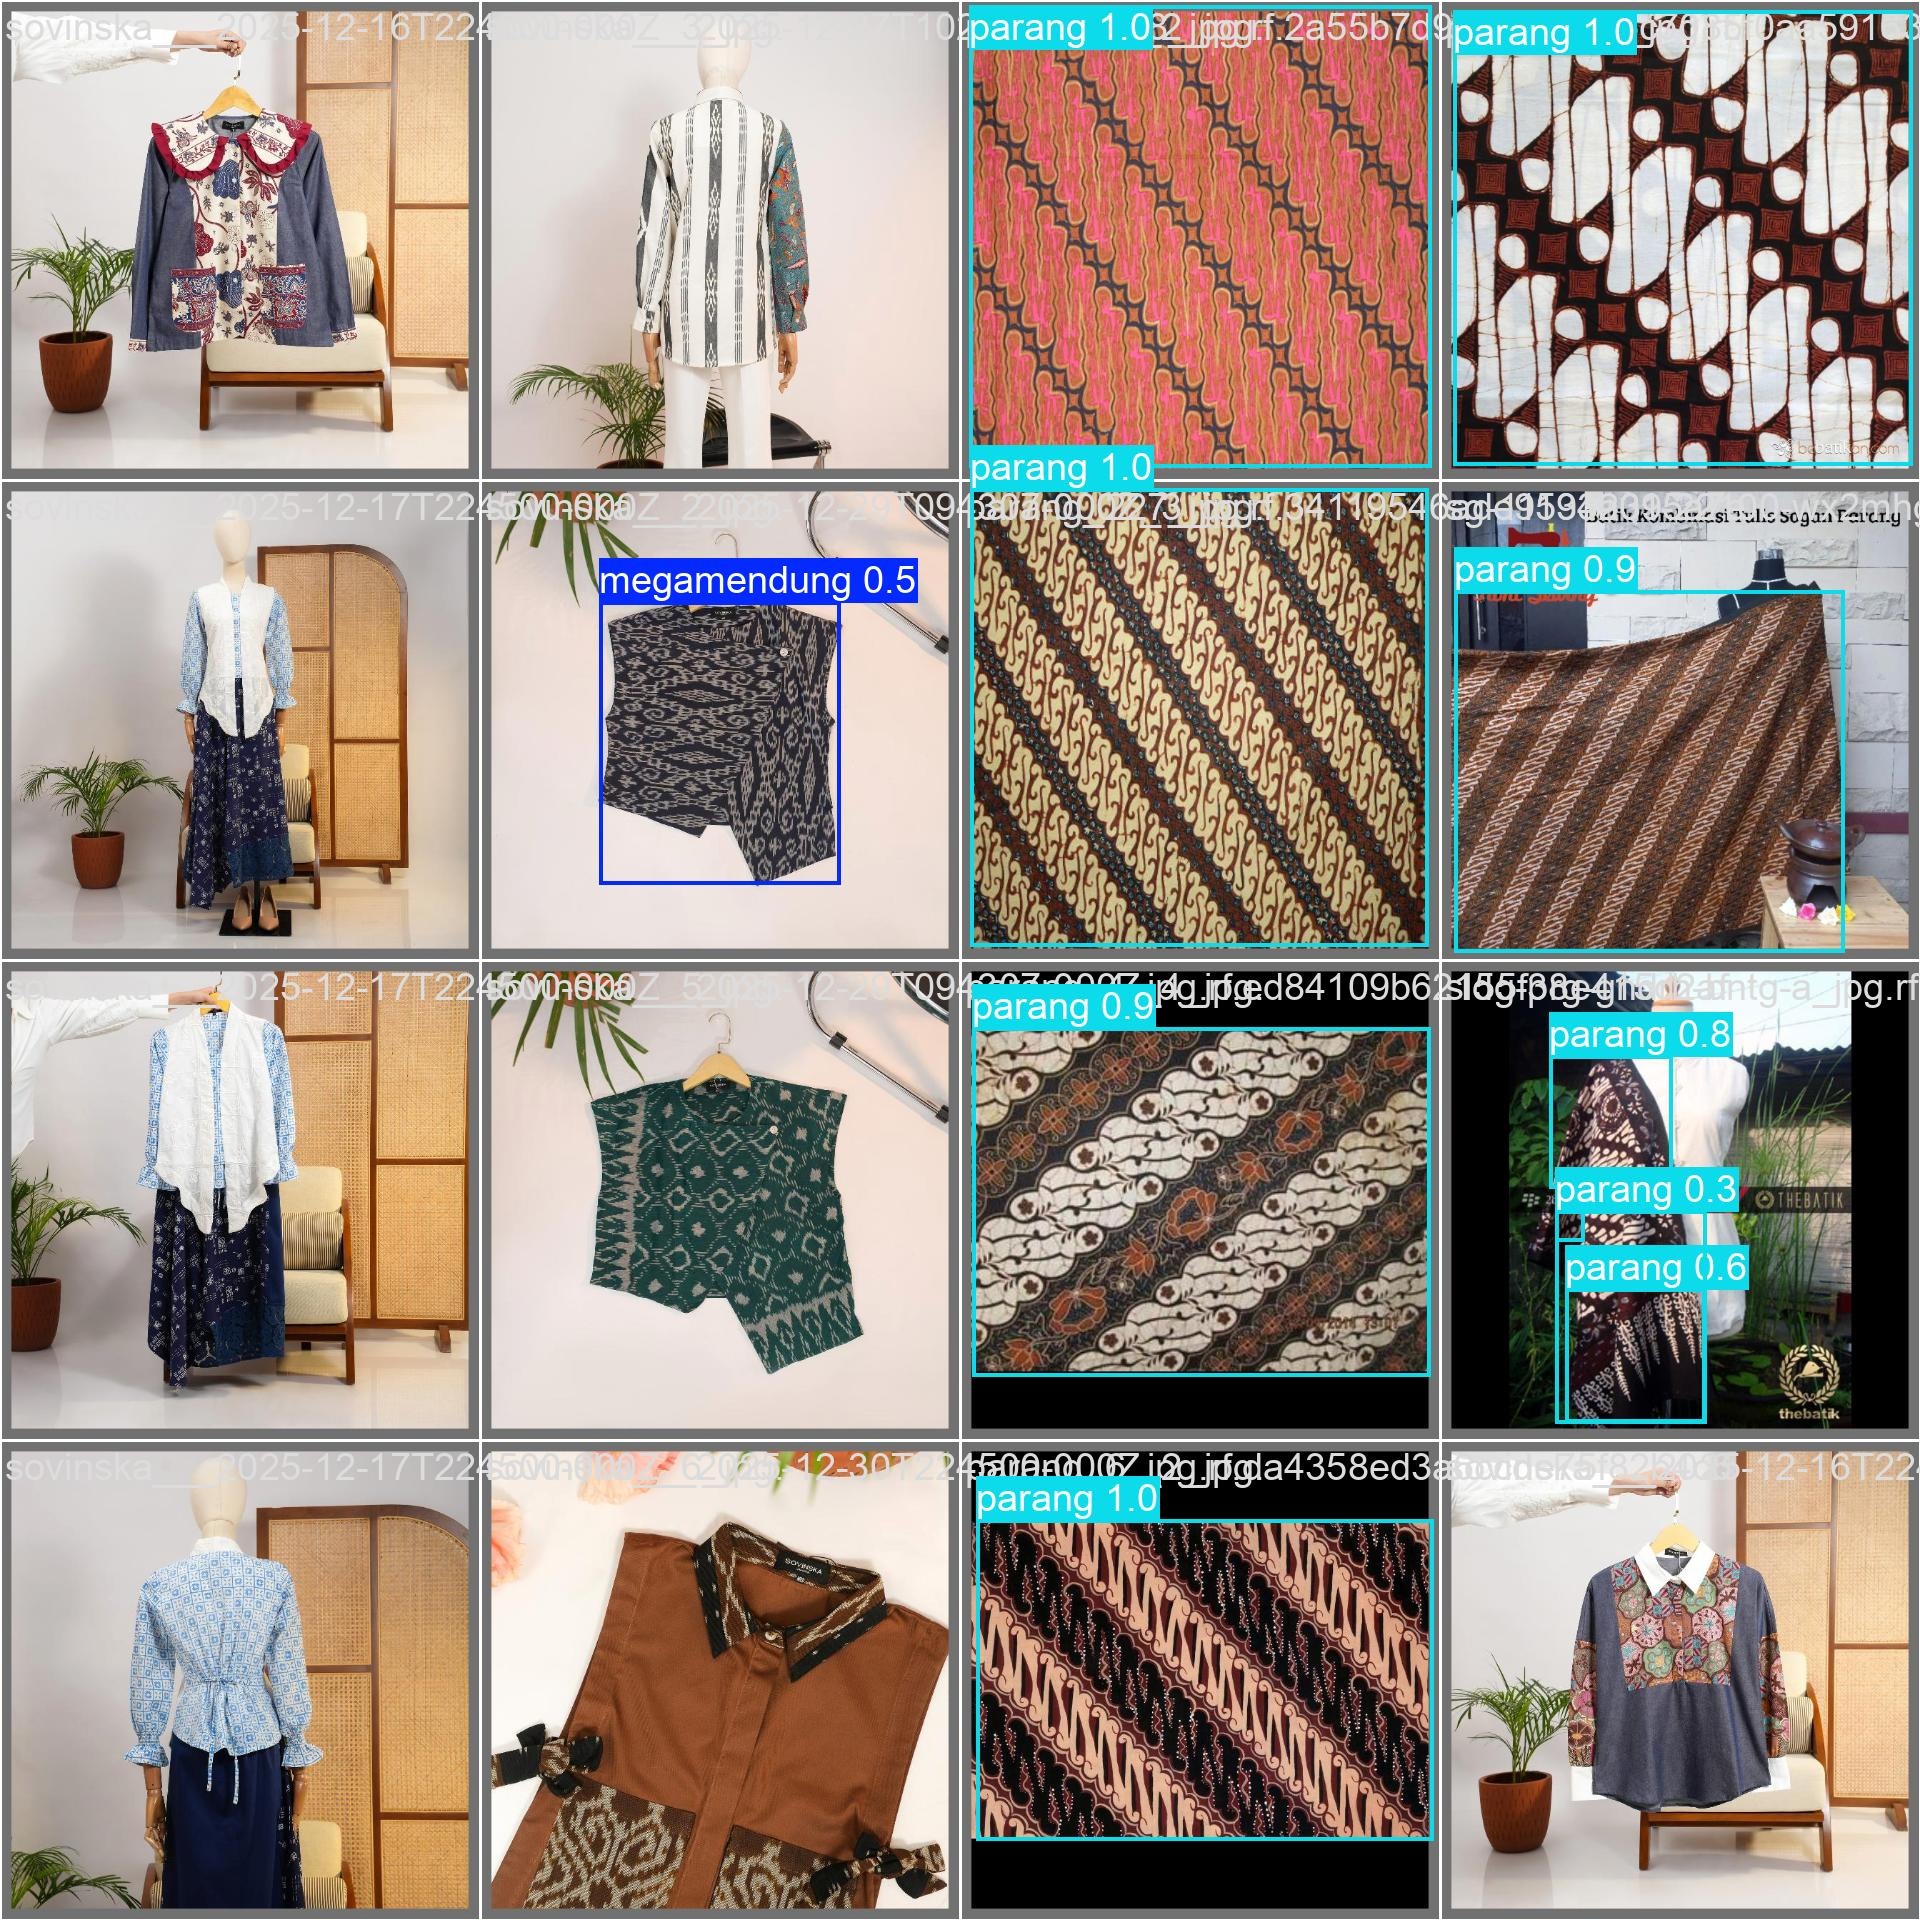



=== Batch 2 ===


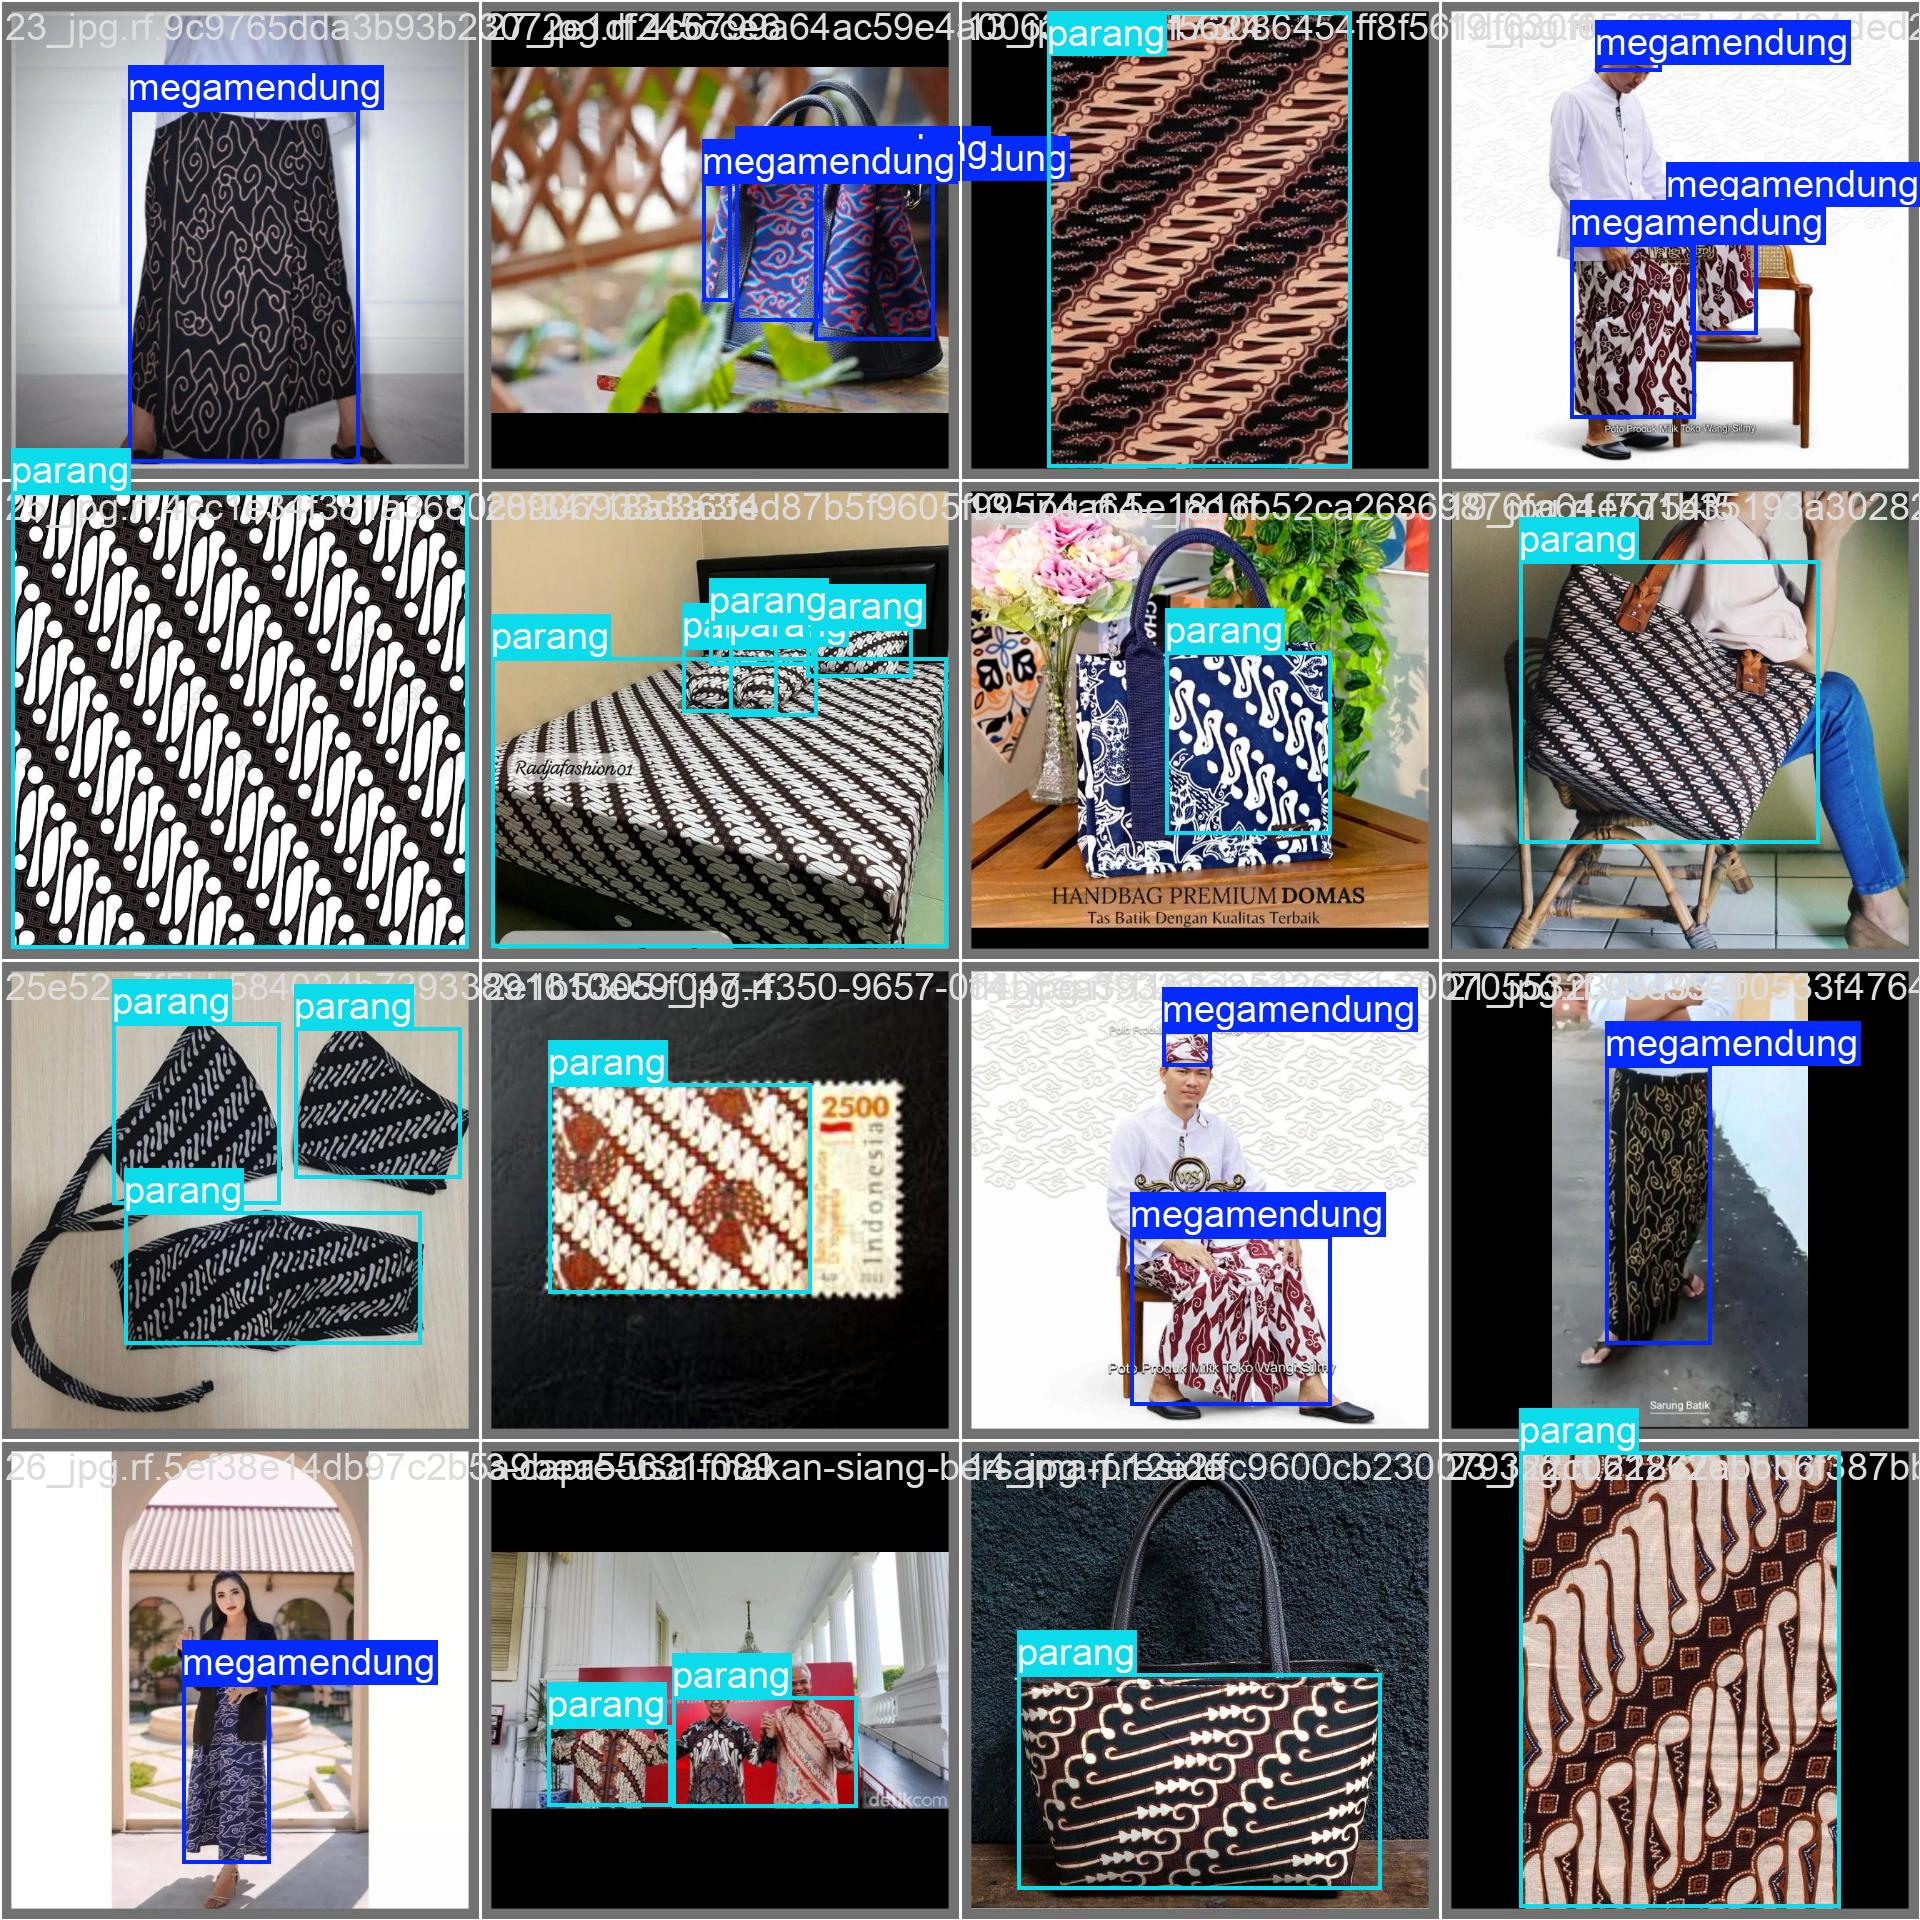

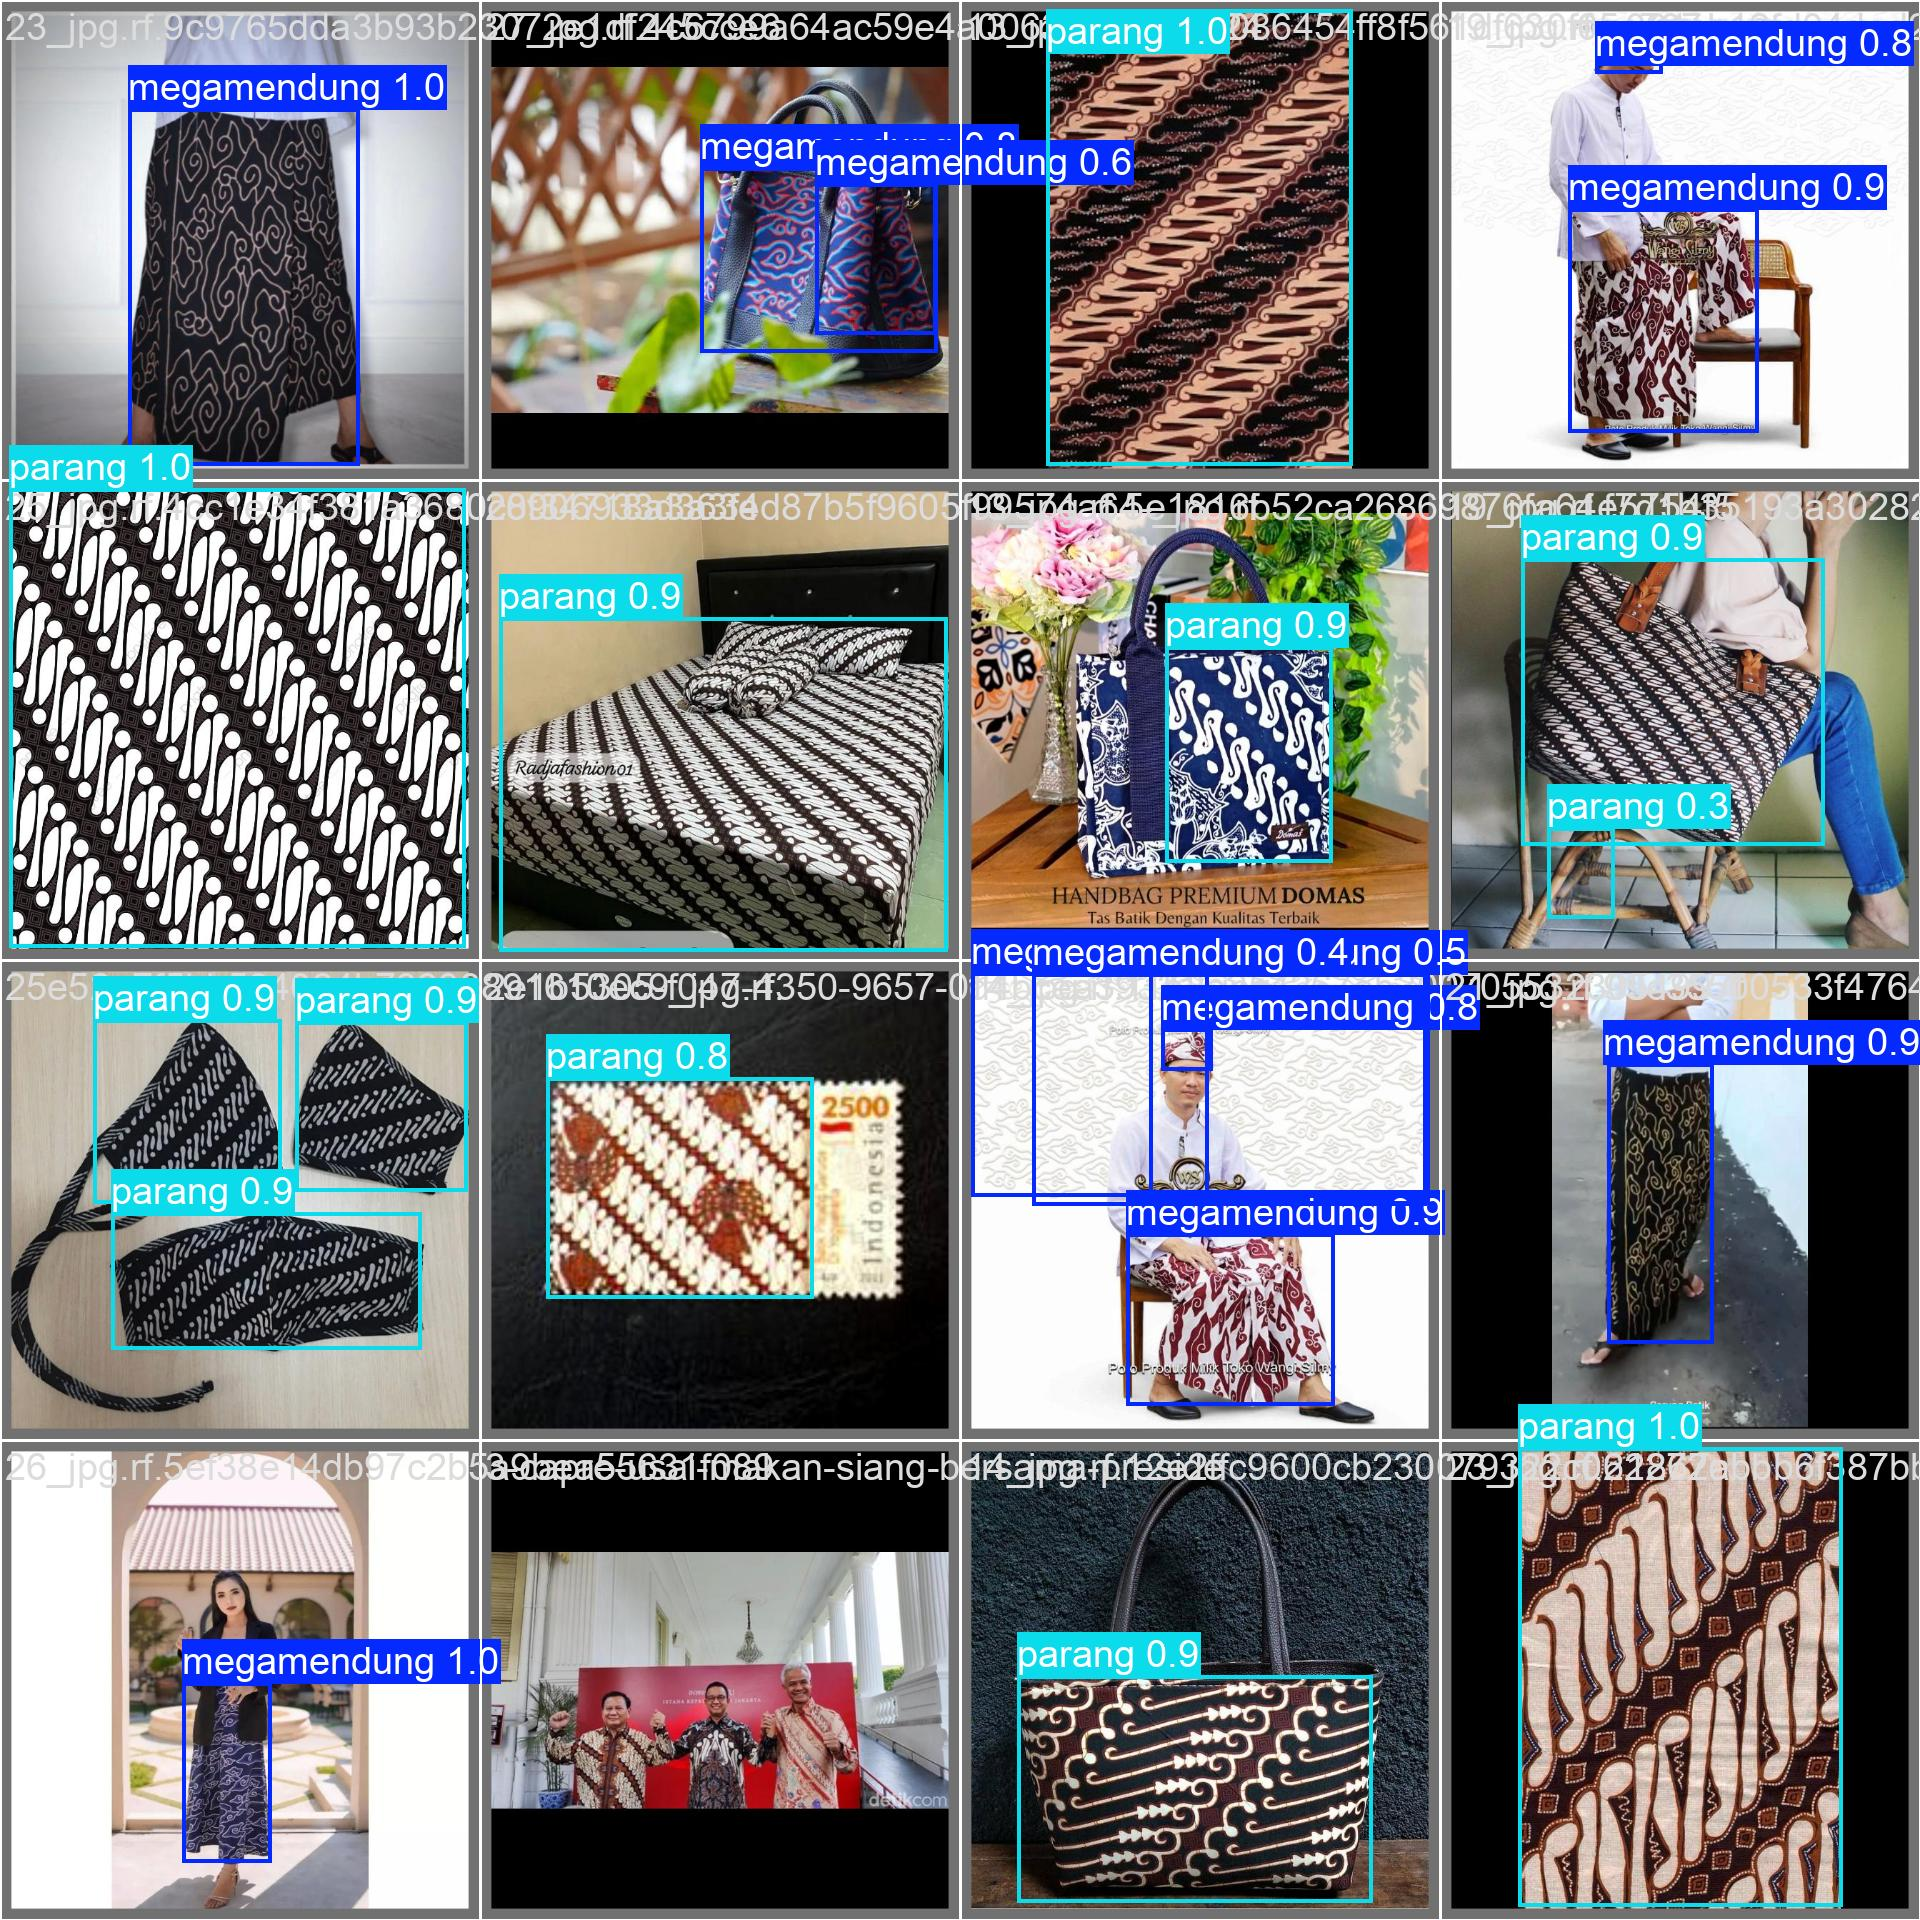



=== Batch 3 ===


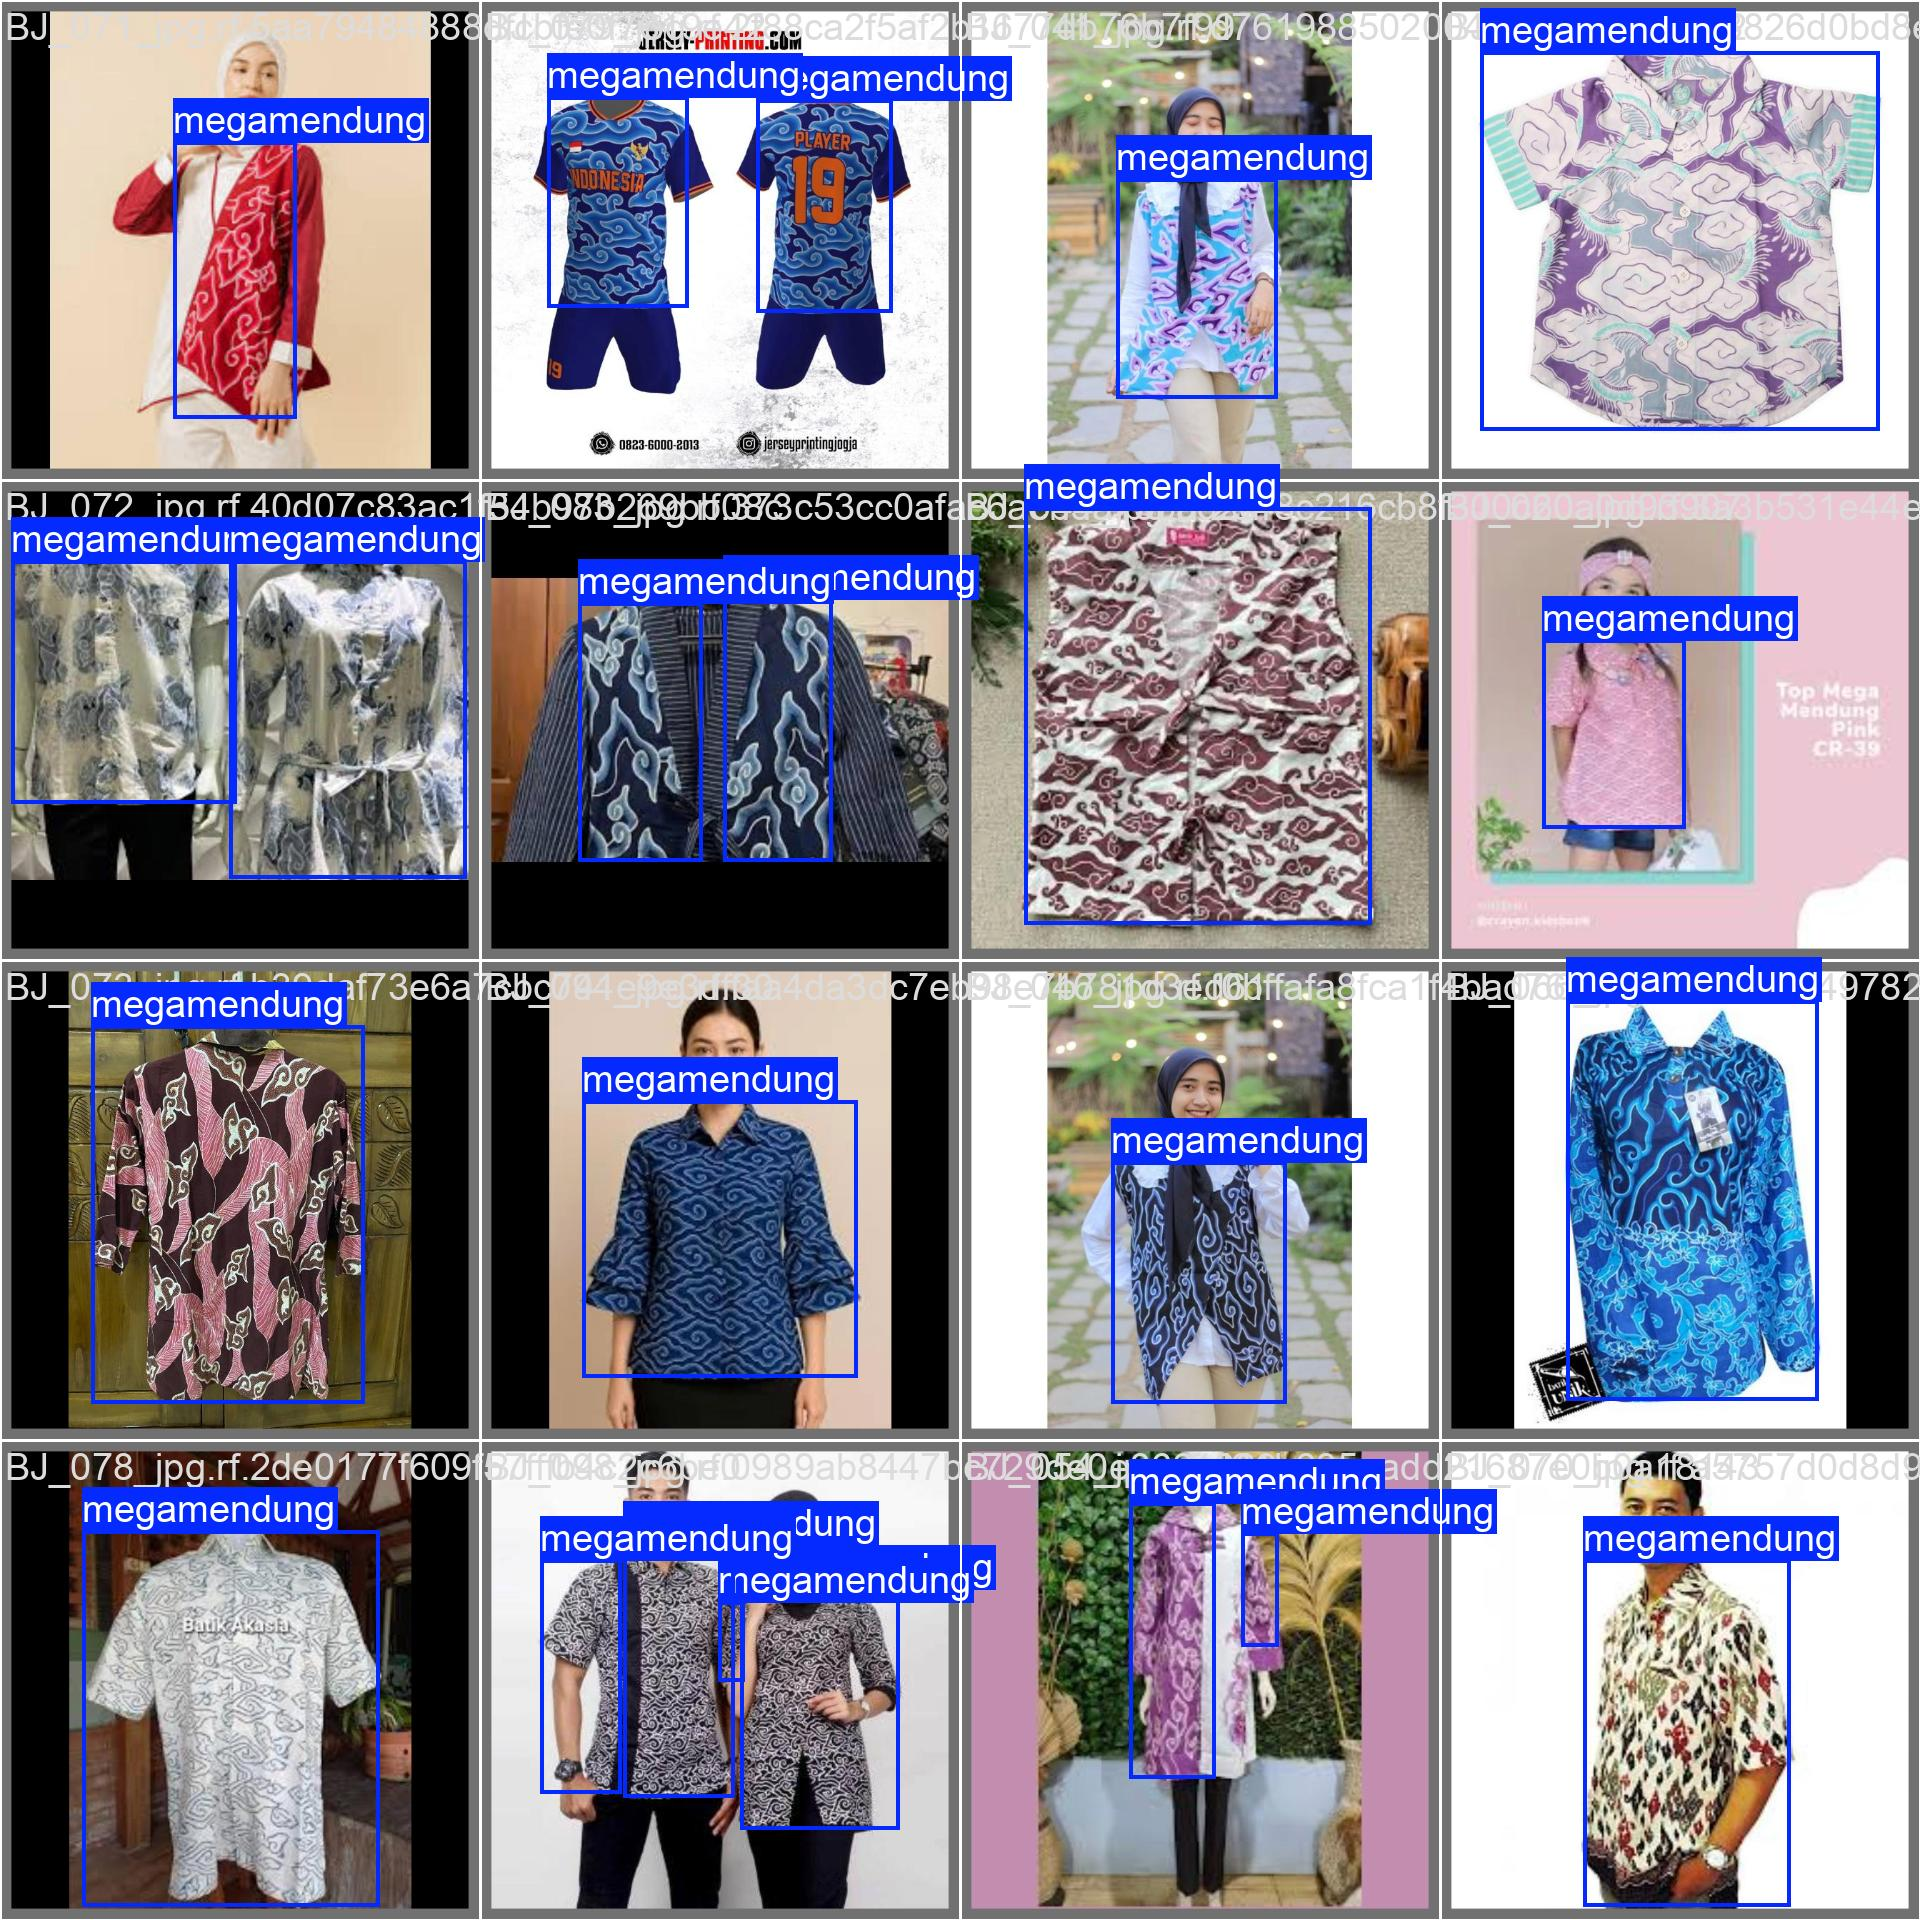

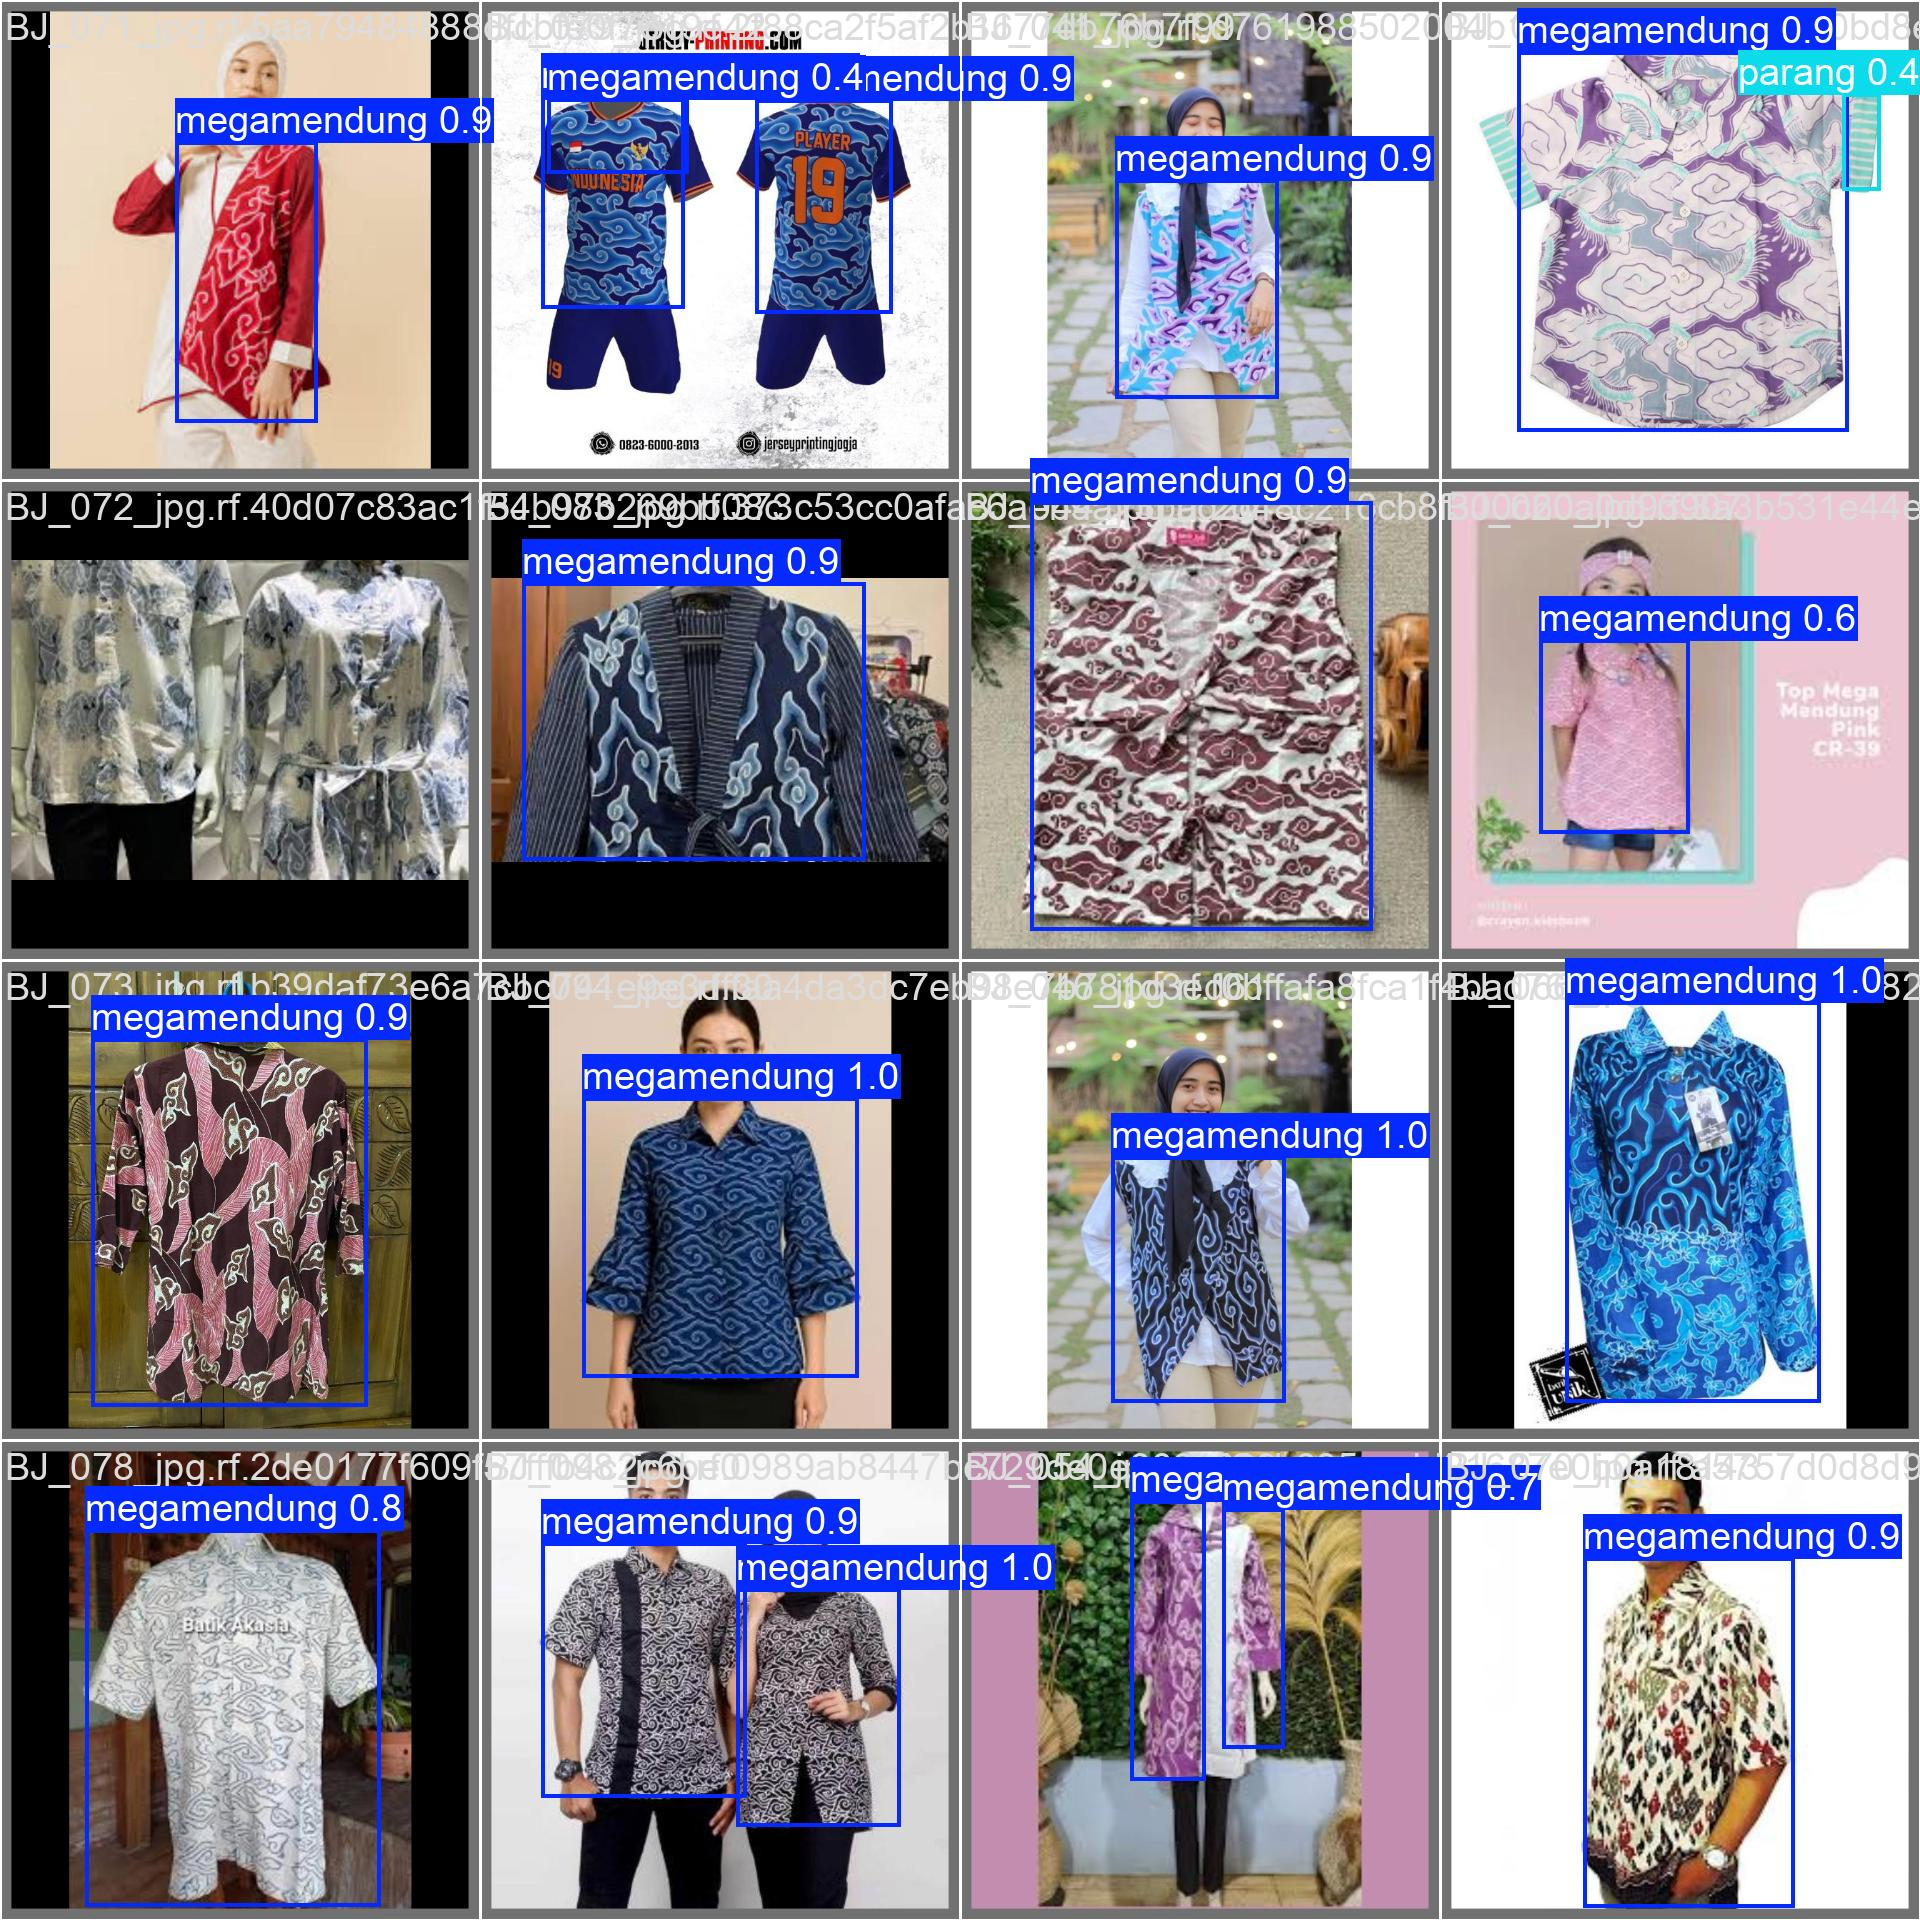

In [13]:

print("\n=== 4. Contoh Hasil Prediksi pada Data Validasi ===")
# Menampilkan contoh gambar yang diprediksi model
for i in range(3):
    print(f"\n\n=== Batch {i + 1} ===")
    display(Image(filename=os.path.join(
        output_dir, f'val_batch{i}_labels.jpg'), width=800))
    display(Image(filename=os.path.join(
        output_dir, f'val_batch{i}_pred.jpg'), width=800))

## Export ke TFlite

In [14]:
from ultralytics import YOLO

# 1. Load model terbaik hasil training tadi
best_model_path = 'project_batik/hasil_training/weights/best.pt'
model = YOLO(best_model_path)

print(f"Sedang mengonversi model: {best_model_path} ke tflite...")

# 2. Lakukan Export
# dynamic=False -> Kita set False agar performa lebih stabil di mobile (static input size)
success = model.export(format='tflite', dynamic=False)

print(f"Export selesai: {success}")

Sedang mengonversi model: project_batik/hasil_training/weights/best.pt ke tflite...
Ultralytics 8.3.245 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'project_batik/hasil_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 20 packages in 5.72s
Prepared 11 packages in 6.28s
Installed 11 packages in 391ms
 + ai-edge-litert==2.1.0
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + coloredlogs==15

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.81...
ONNX: export success ✅ 2.1s, saved as 'project_batik/hasil_training/weights/best.onnx' (10.2 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 48.3files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at 'project_batik/hasil_training/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 6, 8400), dtype=tf.float32, name=None)
Captures:
  137830262553104: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  137830262551568: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  137830262552336: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  137830204361424: TensorSpec(shape=(4, 2), dtype=tf.int32, name=N

In [15]:
from google.colab import files

# Download Model tflite
tflite_path = 'project_batik/hasil_training/weights/best_saved_model/best_float32.tflite'
if os.path.exists(tflite_path):
    print("Mendownload best.tflite...")
    files.download(tflite_path)
    print("Download selesai.")
else:
    print("File tflite tidak ditemukan.")

Mendownload best.tflite...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download selesai.
